In [1]:
import pickle
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import glob
import xarray as xr
plt.rcParams['text.usetex'] = True

In [2]:
path = '/pscratch/sd/m/mckenna/dharma_post/'

bin_file = 'cntl_bin_ice_sounding_time_series.pkl'
bin_sip_file = 'sip_bin_ice_sounding_time_series.pkl'
bin_sip_10x_file = 'sip_10x_bin_ice_sounding_time_series.pkl'

bin_hm_file = 'cntl_bin_ice_hm_sounding_time_series.pkl'
bin_sip_hm_file = 'sip_bin_ice_hm_sounding_time_series.pkl'
bin_sip_10x_hm_file = 'sip_10x_bin_ice_hm_sounding_time_series.pkl'

bulk_file = 'cntl_bulk_ice_ABIFM_sounding_time_series.pkl'
bulk_sip_file = 'sip_bulk_ice_ABIFM_sounding_time_series.pkl'
bulk_sip_10x_file = 'sip_10x_bulk_ice_ABIFM_sounding_time_series.pkl'

bulk_hm_file = 'cntl_bulk_ice_ABIFM_hm_sounding_time_series.pkl'
bulk_sip_hm_file = 'sip_bulk_ice_ABIFM_hm_sounding_time_series.pkl'
bulk_sip_10x_hm_file = 'sip_10x_bulk_ice_ABIFM_hm_sounding_time_series.pkl'

In [3]:
with open(path+bin_file, 'rb') as file:
    bin_dict = pickle.load(file)
with open(path+bin_sip_file, 'rb') as file:
    bin_sip_dict = pickle.load(file)
with open(path+bin_sip_10x_file, 'rb') as file:
    bin_sip_10x_dict = pickle.load(file)

with open(path+bin_hm_file, 'rb') as file:
    bin_hm_dict = pickle.load(file)
with open(path+bin_sip_hm_file, 'rb') as file:
    bin_sip_hm_dict = pickle.load(file)
with open(path+bin_sip_10x_hm_file, 'rb') as file:
    bin_sip_10x_hm_dict = pickle.load(file)

In [4]:
with open(path+bulk_file, 'rb') as file:
    bulk_dict = pickle.load(file)
with open(path+bulk_sip_file, 'rb') as file:
    bulk_sip_dict = pickle.load(file)
with open(path+bulk_sip_10x_file, 'rb') as file:
    bulk_sip_10x_dict = pickle.load(file)

with open(path+bulk_hm_file, 'rb') as file:
    bulk_hm_dict = pickle.load(file)
with open(path+bulk_sip_hm_file, 'rb') as file:
    bulk_sip_hm_dict = pickle.load(file)
with open(path+bulk_sip_10x_hm_file, 'rb') as file:
    bulk_sip_10x_hm_dict = pickle.load(file)

In [8]:
def running_mean(arr, window):
    kernel = np.ones(window) / window
    return np.convolve(arr, kernel, mode='same')

running_mean_window = 20

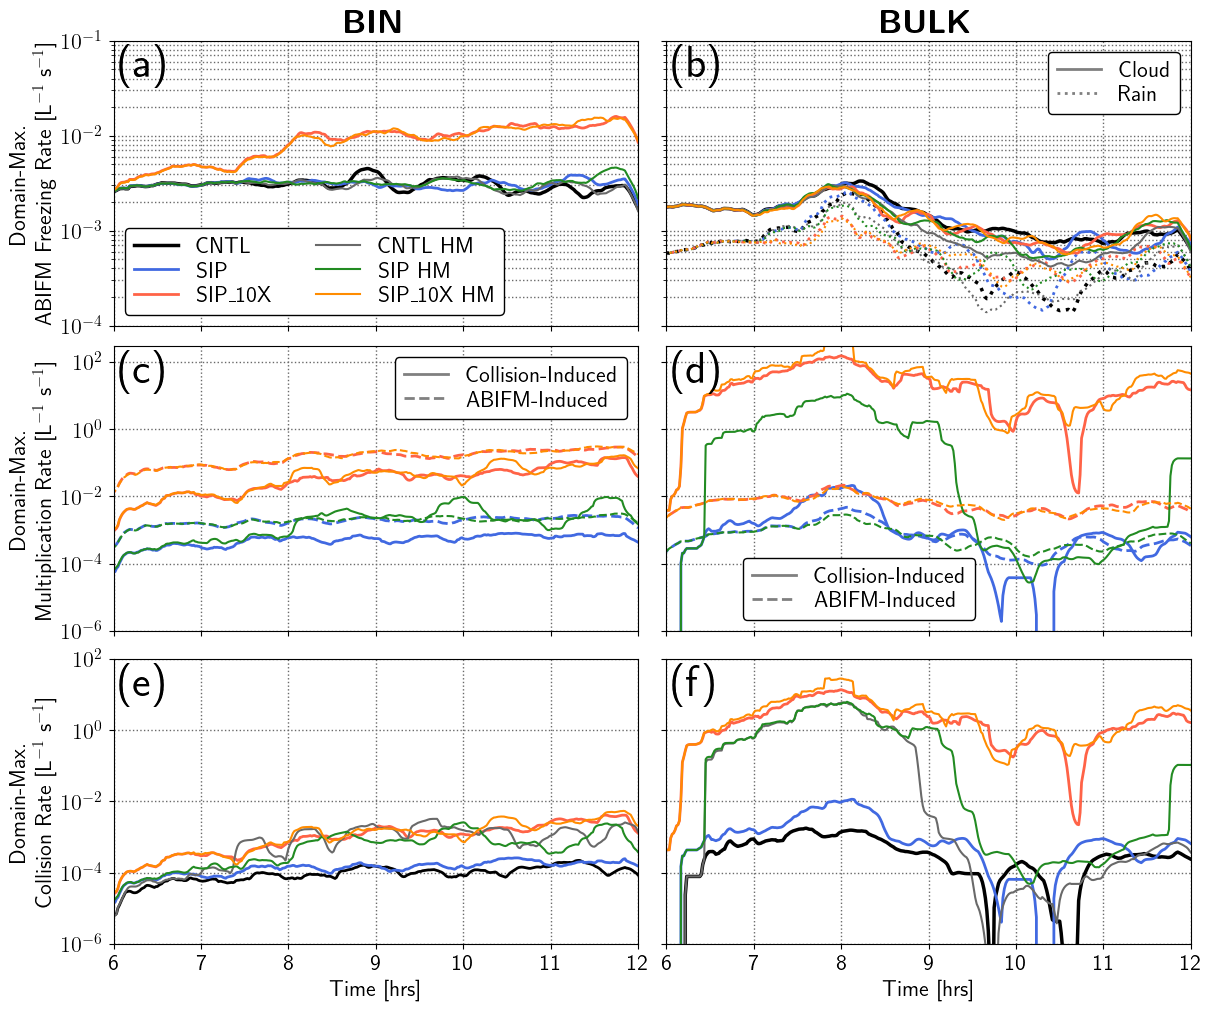

In [23]:
fig = plt.figure(figsize=(12,10),constrained_layout=True)
ax1 = fig.add_subplot(321)
ax2 = fig.add_subplot(322)
ax3 = fig.add_subplot(323)
ax4 = fig.add_subplot(324)
ax5 = fig.add_subplot(325)
ax6 = fig.add_subplot(326)
axlist = [ax1,ax2,ax3,ax4,ax5,ax6]
Fontsize=16
for ax in axlist:
    ax.grid(which='both',ls='dotted',lw=1,c='dimgrey')
    ax.tick_params(labelsize=Fontsize)
    ax.set_xlim(6,12)
    ax.set_xticks(np.arange(6,13,1))
    ax.set_xticklabels([])
    ax.set_yscale('log')

ax5.set_xlabel('Time [hrs]',fontsize=Fontsize)
ax6.set_xlabel('Time [hrs]',fontsize=Fontsize)
ax5.set_xticklabels(['6','7','8','9','10','11','12'])
ax6.set_xticklabels(['6','7','8','9','10','11','12'])

ax3.set_ylabel('Domain-Max.\nMultiplication Rate [L$^{-1}$ s$^{-1}$]',fontsize=Fontsize)
ax5.set_ylabel('Domain-Max.\nCollision Rate [L$^{-1}$ s$^{-1}$]',fontsize=Fontsize)

cntl_hm_color = 'dimgrey'
sip_hm_color = 'forestgreen'
sip_10x_hm_color = 'darkorange'

#============================================
# ABIFM Freezing Rate
#============================================
ax1.set_ylabel('Domain-Max.\nABIFM Freezing Rate [L$^{-1}$ s$^{-1}$]',fontsize=Fontsize)


# Bin
ax1.plot(bin_dict['time']/3600.,running_mean(bin_dict['max_in_imm']*1.e3,running_mean_window),lw=2.5,c='k',label='CNTL')
ax1.plot(bin_sip_dict['time']/3600.,running_mean(bin_sip_dict['max_in_imm']*1.e3,running_mean_window),lw=2,c='royalblue',label='SIP')
ax1.plot(bin_sip_10x_dict['time']/3600.,running_mean(bin_sip_10x_dict['max_in_imm']*1.e3,running_mean_window),lw=2,c='tomato',label='SIP_10X')

ax1.plot(bin_hm_dict['time']/3600.,running_mean(bin_hm_dict['max_in_imm']*1.e3,running_mean_window),lw=1.5,c=cntl_hm_color,label='CNTL HM')
ax1.plot(bin_sip_hm_dict['time']/3600.,running_mean(bin_sip_hm_dict['max_in_imm']*1.e3,running_mean_window),lw=1.5,c=sip_hm_color,label='SIP HM')
ax1.plot(bin_sip_10x_hm_dict['time']/3600.,running_mean(bin_sip_10x_hm_dict['max_in_imm']*1.e3,running_mean_window),lw=1.5,c=sip_10x_hm_color,label='SIP_10X HM')

# Bulk
dum_ls = 'dotted'
ax2.plot(bulk_dict['time']/3600.,running_mean(bulk_dict['max_in_imm_c']*1.e3,running_mean_window),lw=2.5,c='k')
ax2.plot(bulk_dict['time']/3600.,running_mean(bulk_dict['max_in_imm_r']*1.e3,running_mean_window),lw=2.5,c='k',ls=dum_ls)

ax2.plot(bulk_sip_dict['time']/3600.,running_mean(bulk_sip_dict['max_in_imm_c']*1.e3,running_mean_window),lw=2,c='royalblue')
ax2.plot(bulk_sip_dict['time']/3600.,running_mean(bulk_sip_dict['max_in_imm_r']*1.e3,running_mean_window),lw=2,c='royalblue',ls=dum_ls)

ax2.plot(bulk_sip_10x_dict['time']/3600.,running_mean(bulk_sip_10x_dict['max_in_imm_c']*1.e3,running_mean_window),lw=2,c='tomato')
ax2.plot(bulk_sip_10x_dict['time']/3600.,running_mean(bulk_sip_10x_dict['max_in_imm_r']*1.e3,running_mean_window),lw=2,c='tomato',ls=dum_ls)


ax2.plot(bulk_hm_dict['time']/3600.,running_mean(bulk_hm_dict['max_in_imm_c']*1.e3,running_mean_window),lw=1.5,c=cntl_hm_color)
ax2.plot(bulk_sip_hm_dict['time']/3600.,running_mean(bulk_sip_hm_dict['max_in_imm_c']*1.e3,running_mean_window),lw=1.5,c=sip_hm_color)
ax2.plot(bulk_sip_10x_hm_dict['time']/3600.,running_mean(bulk_sip_10x_hm_dict['max_in_imm_c']*1.e3,running_mean_window),lw=1.5,c=sip_10x_hm_color)

ax2.plot(bulk_hm_dict['time']/3600.,running_mean(bulk_hm_dict['max_in_imm_r']*1.e3,running_mean_window),lw=1.5,c=cntl_hm_color,ls='dotted')
ax2.plot(bulk_sip_hm_dict['time']/3600.,running_mean(bulk_sip_hm_dict['max_in_imm_r']*1.e3,running_mean_window),lw=1.5,c=sip_hm_color,ls='dotted')
ax2.plot(bulk_sip_10x_hm_dict['time']/3600.,running_mean(bulk_sip_10x_hm_dict['max_in_imm_r']*1.e3,running_mean_window),lw=1.5,c=sip_10x_hm_color,ls='dotted')

ax1.set_ylim(1.e-4,1.e-1)
ax2.set_ylim(1.e-4,1.e-1)
ax1.legend(loc='lower left',fontsize=Fontsize*1,framealpha=1,edgecolor='k',labelspacing=0.2,ncol=2)

legend_elements = [
    Line2D([0], [0], color='gray', lw=2.0, ls='solid', label=r'Cloud'),
    Line2D([0], [0], color='gray', lw=2.0, ls=dum_ls, label=r'Rain')
]
ax2.legend(handles=legend_elements, fontsize=Fontsize, loc='upper right',labelspacing=0.2,framealpha=1,edgecolor='k')

ax1.set_yticks(10.**np.arange(-4,0,1))
ax2.set_yticks(10.**np.arange(-4,0,1))
ax2.set_yticklabels([])

#============================================
# Multiplication Rate
#============================================
ax3.plot(bin_sip_dict['time']/3600.,running_mean(bin_sip_dict['max_sh_coag']*1.e3,running_mean_window),lw=2,c='royalblue')
ax3.plot(bin_sip_10x_dict['time']/3600.,running_mean(bin_sip_10x_dict['max_sh_coag']*1.e3,running_mean_window),lw=2,c='tomato')

ax3.plot(bin_sip_dict['time']/3600.,running_mean(bin_sip_dict['max_sh_in']*1.e3,running_mean_window),lw=2,c='royalblue',ls='dashed')
ax3.plot(bin_sip_10x_dict['time']/3600.,running_mean(bin_sip_10x_dict['max_sh_in']*1.e3,running_mean_window),lw=2,c='tomato',ls='dashed')

ax3.plot(bin_sip_hm_dict['time']/3600.,running_mean(bin_sip_hm_dict['max_sh_coag']*1.e3,running_mean_window),lw=1.5,c=sip_hm_color,ls='solid')
ax3.plot(bin_sip_10x_hm_dict['time']/3600.,running_mean(bin_sip_10x_hm_dict['max_sh_coag']*1.e3,running_mean_window),lw=1.5,c=sip_10x_hm_color,ls='solid')

ax3.plot(bin_sip_hm_dict['time']/3600.,running_mean(bin_sip_hm_dict['max_sh_in']*1.e3,running_mean_window),lw=1.5,c=sip_hm_color,ls='dashed')
ax3.plot(bin_sip_10x_hm_dict['time']/3600.,running_mean(bin_sip_10x_hm_dict['max_sh_in']*1.e3,running_mean_window),lw=1.5,c=sip_10x_hm_color,ls='dashed')


ax4.plot(bulk_sip_dict['time']/3600.,running_mean(bulk_sip_dict['max_sh_coag']*1.e3,running_mean_window),lw=2,c='royalblue')
ax4.plot(bulk_sip_10x_dict['time']/3600.,running_mean(bulk_sip_10x_dict['max_sh_coag']*1.e3,running_mean_window),lw=2,c='tomato')

ax4.plot(bulk_sip_dict['time']/3600.,running_mean(bulk_sip_dict['max_sh_in_r']*1.e3,running_mean_window),lw=2,c='royalblue',ls='dashed')
ax4.plot(bulk_sip_10x_dict['time']/3600.,running_mean(bulk_sip_10x_dict['max_sh_in_r']*1.e3,running_mean_window),lw=2,c='tomato',ls='dashed')


ax4.plot(bulk_sip_hm_dict['time']/3600.,running_mean(bulk_sip_hm_dict['max_sh_coag']*1.e3,running_mean_window),lw=1.5,c=sip_hm_color)
ax4.plot(bulk_sip_10x_hm_dict['time']/3600.,running_mean(bulk_sip_10x_hm_dict['max_sh_coag']*1.e3,running_mean_window),lw=1.5,c=sip_10x_hm_color)

ax4.plot(bulk_sip_hm_dict['time']/3600.,running_mean(bulk_sip_hm_dict['max_sh_in_r']*1.e3,running_mean_window),lw=1.5,c=sip_hm_color,ls='dashed')
ax4.plot(bulk_sip_10x_hm_dict['time']/3600.,running_mean(bulk_sip_10x_hm_dict['max_sh_in_r']*1.e3,running_mean_window),lw=1.5,c=sip_10x_hm_color,ls='dashed')

ax3.set_ylim(1.e-6,3.e2)
ax4.set_ylim(1.e-6,3.e2)


legend_elements = [
    Line2D([0], [0], color='gray', lw=2.0, ls='solid', label=r'Collision-Induced'),
    Line2D([0], [0], color='gray', lw=2.0, ls='dashed', label=r'ABIFM-Induced')
]
ax3.legend(handles=legend_elements, fontsize=Fontsize, loc='upper right',labelspacing=0.2,framealpha=1,edgecolor='k')
ax4.legend(handles=legend_elements, fontsize=Fontsize, loc='lower left',labelspacing=0.2,framealpha=1,edgecolor='k',bbox_to_anchor=(0.125,0.))

ax3.set_yticks(10.**np.arange(-6,2.3,2))
ax4.set_yticks(10.**np.arange(-6,2.3,2))
ax4.set_yticklabels([])

#============================================
# Collision Rate
#============================================
ax5.plot(bin_dict['time']/3600.,running_mean(bin_dict['max_sh_coag_raw']*1.e3,running_mean_window),lw=2,c='k',label='BIN CNTL')
ax5.plot(bin_sip_dict['time']/3600.,running_mean(bin_sip_dict['max_sh_coag_raw']*1.e3,running_mean_window),lw=2,c='royalblue',label='BIN SIP')
ax5.plot(bin_sip_10x_dict['time']/3600.,running_mean(bin_sip_10x_dict['max_sh_coag_raw']*1.e3,running_mean_window),lw=2,c='tomato',label='BIN SIP 10X')

ax5.plot(bin_hm_dict['time']/3600.,running_mean(bin_hm_dict['max_sh_coag_raw']*1.e3,running_mean_window),lw=1.5,c=cntl_hm_color)
ax5.plot(bin_sip_hm_dict['time']/3600.,running_mean(bin_sip_hm_dict['max_sh_coag_raw']*1.e3,running_mean_window),lw=1.5,c=sip_hm_color)
ax5.plot(bin_sip_10x_hm_dict['time']/3600.,running_mean(bin_sip_10x_hm_dict['max_sh_coag_raw']*1.e3,running_mean_window),lw=1.5,c=sip_10x_hm_color)


ax6.plot(bulk_dict['time']/3600.,running_mean(bulk_dict['max_sh_coag_raw']*1.e3,running_mean_window),lw=2.5,c='k')
ax6.plot(bulk_sip_dict['time']/3600.,running_mean(bulk_sip_dict['max_sh_coag_raw']*1.e3,running_mean_window),lw=2,c='royalblue')
ax6.plot(bulk_sip_10x_dict['time']/3600.,running_mean(bulk_sip_10x_dict['max_sh_coag_raw']*1.e3,running_mean_window),lw=2,c='tomato')

ax6.plot(bulk_hm_dict['time']/3600.,running_mean(bulk_hm_dict['max_sh_coag_raw']*1.e3,running_mean_window),lw=1.5,c=cntl_hm_color)
ax6.plot(bulk_sip_hm_dict['time']/3600.,running_mean(bulk_sip_hm_dict['max_sh_coag_raw']*1.e3,running_mean_window),lw=1.5,c=sip_hm_color)
ax6.plot(bulk_sip_10x_hm_dict['time']/3600.,running_mean(bulk_sip_10x_hm_dict['max_sh_coag_raw']*1.e3,running_mean_window),lw=1.5,c=sip_10x_hm_color)

ax5.set_ylim(1.e-6,1.e2)
ax6.set_ylim(1.e-6,1.e2)

ax5.set_yticks(10.**np.arange(-6,3,2))
ax6.set_yticks(10.**np.arange(-6,3,2))
ax6.set_yticklabels([])


labs = [r'\textbf{(a)}',\
        r'\textbf{(b)}',\
        r'\textbf{(c)}',\
        r'\textbf{(d)}',\
        r'\textbf{(e)}',\
        r'\textbf{(f)}']
labs = ['(a)','(b)','(c)','(d)','(e)','(f)']
for ii,ax in enumerate(axlist):
    ax.text(0.01,0.99,labs[ii],fontsize=Fontsize*2.,transform=ax.transAxes,ha='left',va='top')


ax1.set_title(r'\textbf{BIN}',fontsize=Fontsize*1.5)
ax2.set_title(r'\textbf{BULK}',fontsize=Fontsize*1.5)

plt.show()
plt.close()

In [5]:
post_path = '/pscratch/sd/m/mckenna/dharma_3d/'

ii=1
bin_cntl_3d_files = sorted(glob.glob(post_path+'cntl_bin_ice/*nc'))[::ii]
bin_cntl_hm_3d_files = sorted(glob.glob(post_path+'cntl_bin_ice_hm/*nc'))[::ii]
bin_sip_3d_files  = sorted(glob.glob(post_path+'sip_bin_ice/*nc'))[::ii]
bin_sip_hm_3d_files  = sorted(glob.glob(post_path+'sip_bin_ice_hm/*nc'))[::ii]
bin_sip10x_3d_files  = sorted(glob.glob(post_path+'sip_10x_bin_ice/*nc'))[::ii]
bin_sip10x_hm_3d_files  = sorted(glob.glob(post_path+'sip_10x_bin_ice_hm/*nc'))[::ii]
                                       
num_bin_cntl_3d_files = len(bin_cntl_3d_files)
num_bin_cntl_hm_3d_files = len(bin_cntl_hm_3d_files)
num_bin_sip_3d_files = len(bin_sip_3d_files)
num_bin_sip_hm_3d_files = len(bin_sip_hm_3d_files)
num_bin_sip10x_3d_files = len(bin_sip10x_3d_files)
num_bin_sip10x_hm_3d_files = len(bin_sip10x_hm_3d_files)

print(num_bin_cntl_3d_files)
print(num_bin_cntl_hm_3d_files)
print(num_bin_sip_3d_files)
print(num_bin_sip10x_3d_files)
print(num_bin_sip10x_hm_3d_files)

37
37
37
37
37


In [6]:
# ============================================================
# PDFs of Ni from 3D BIN simulations
# Left : all cloudy points     (qi > 1e-3 g/kg)
# Right: cloudy updraft points (qi > 1e-3 g/kg AND w_interp > 1 m/s)
# ni [#/cm3] -> L-1 (*1e3); qi threshold = 1e-6 kg/kg
# Histogram counts accumulated file-by-file to avoid memory issues
# ============================================================
Fontsize    = 14
nbins       = 30
log10_edges = np.linspace(-4, 3.5, nbins + 1)   # L-1 space: 0.01 to 10000
qi_thresh   = 1.e-6    # kg/kg  (= 1e-3 g/kg)
w_thresh    = 1.0      # m/s
ni_thresh   = 1.e-4    # L-1 (exclude near-zero ice)

sim_labels    = [r'\textbf{CNTL}', r'\textbf{SIP}', r'\textbf{SIP\_10X}',r'\textbf{CNTL\_HM}', r'\textbf{SIP\_HM}', r'\textbf{SIP\_10X\_HM}']
sim_colors    = ['k', 'royalblue', 'tomato','k', 'royalblue', 'tomato']
sim_lws       = [2, 2, 2, 2, 2, 2]
sim_lss       = ['solid','solid','solid','dotted','dotted','dotted']
sim_file_lists = [bin_cntl_3d_files, bin_sip_3d_files, bin_sip10x_3d_files, bin_cntl_hm_3d_files, bin_sip_hm_3d_files, bin_sip10x_hm_3d_files]

# Accumulate counts for each sim (two masks: all cloudy, cloudy updraft)
counts_cld  = []   # one array per sim
counts_up   = []

for i,file_list in enumerate(sim_file_lists):
    print(sim_labels[i])
    c_cld = np.zeros(nbins)
    c_up  = np.zeros(nbins)
    for fpath in file_list:
        with xr.open_dataset(fpath, decode_times=False) as ds_f:
            ni_raw = ds_f['ni'].values.ravel()          # #/cm3
            qi_raw = ds_f['qi'].values.ravel()          # kg/kg
            w_raw  = ds_f['w_interp'].values.ravel()    # m/s

        ni_L = ni_raw * 1.e3                            # -> L-1

        mask_cld = (qi_raw > qi_thresh) & (ni_L > ni_thresh)
        mask_up  = mask_cld & (w_raw > w_thresh)

        if mask_cld.any():
            h, _ = np.histogram(np.log10(ni_L[mask_cld]), bins=log10_edges)
            c_cld += h
        if mask_up.any():
            h, _ = np.histogram(np.log10(ni_L[mask_up]),  bins=log10_edges)
            c_up  += h

    counts_cld.append(c_cld)
    counts_up.append(c_up)

\textbf{CNTL}


/global/common/software/m1657/mckenna/flextrkr/lib/python3.11/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


\textbf{SIP}
\textbf{SIP\_10X}
\textbf{CNTL\_HM}
\textbf{SIP\_HM}
\textbf{SIP\_10X\_HM}


In [7]:
bulk_cntl_3d_files = sorted(glob.glob(post_path+'cntl_bulk_ice_ABIFM/*nc'))[::ii]
bulk_sip_3d_files = sorted(glob.glob(post_path+'sip_bulk_ice_ABIFM/*nc'))[::ii]
bulk_sip_10x_3d_files = sorted(glob.glob(post_path+'sip_10x_bulk_ice_ABIFM/*nc'))[::ii]
bulk_cntl_hm_3d_files = sorted(glob.glob(post_path+'cntl_bulk_ice_ABIFM_hm/*nc'))[::ii]
bulk_sip_hm_3d_files = sorted(glob.glob(post_path+'sip_bulk_ice_ABIFM_hm/*nc'))[::ii]
bulk_sip_10x_hm_3d_files = sorted(glob.glob(post_path+'sip_10x_bulk_ice_ABIFM_hm/*nc'))[::ii]

num_bulk_cntl_3d_files = len(bulk_cntl_3d_files)
num_bulk_sip_3d_files = len(bulk_sip_3d_files)
num_bulk_sip_10x_3d_files = len(bulk_sip_10x_3d_files)
num_bulk_cntl_hm_3d_files = len(bulk_cntl_hm_3d_files)
num_bulk_sip_hm_3d_files = len(bulk_sip_hm_3d_files)
num_bulk_sip_10x_hm_3d_files = len(bulk_sip_10x_hm_3d_files)

print(num_bulk_cntl_3d_files)
print(num_bulk_sip_3d_files)
print(num_bulk_sip_10x_3d_files)
print(num_bulk_cntl_hm_3d_files)
print(num_bulk_sip_hm_3d_files)
print(num_bulk_sip_10x_hm_3d_files)

37
37
37
37
37
37


In [8]:
# ============================================================
# PDFs of Ni from 3D BULK simulations
# Left : all cloudy points     (qi > 1e-3 g/kg)
# Right: cloudy updraft points (qi > 1e-3 g/kg AND w_interp > 1 m/s)
# ni [#/cm3] -> L-1 (*1e3); qi threshold = 1e-6 kg/kg
# Histogram counts accumulated file-by-file to avoid memory issues
# ============================================================
Fontsize    = 14
nbins       = 30
log10_edges = np.linspace(-4, 3.5, nbins + 1)   # L-1 space: 0.01 to 10000
qi_thresh   = 1.e-6    # kg/kg  (= 1e-3 g/kg)
w_thresh    = 1.0      # m/s
ni_thresh   = 1.e-4    # L-1 (exclude near-zero ice)

bulk_sim_labels    = [r'\textbf{CNTL}', r'\textbf{SIP}', r'\textbf{SIP\_10X}',r'\textbf{CNTL\_HM}', r'\textbf{SIP\_HM}', r'\textbf{SIP\_10X\_HM}']
bulk_sim_colors    = ['k', 'royalblue', 'tomato','k', 'royalblue', 'tomato']
bulk_sim_lws       = [2, 2, 2, 2, 2, 2]
bulk_sim_lss       = ['solid','solid','solid','dotted','dotted','dotted']
bulk_sim_file_lists = [bulk_cntl_3d_files, bulk_sip_3d_files, bulk_sip_10x_3d_files, bulk_cntl_hm_3d_files, bulk_sip_hm_3d_files, bulk_sip_10x_hm_3d_files]

# Accumulate counts for each sim (two masks: all cloudy, cloudy updraft)
bulk_counts_cld  = []   # one array per sim
bulk_counts_up   = []
bulk_counts_cld_qic  = []   # one array per sim
bulk_counts_up_qic   = []

for i,file_list in enumerate(bulk_sim_file_lists):
    print(sim_labels[i])
    c_cld = np.zeros(nbins)
    c_cld_qic = np.zeros(nbins)
    c_up  = np.zeros(nbins)
    c_up_qic  = np.zeros(nbins)
    for fpath in file_list:
        with xr.open_dataset(fpath, decode_times=False) as ds_f:
            nic_raw = ds_f['nic'].values          # #/kg
            nif_raw = ds_f['nif'].values          # #/kg
            nid_raw = ds_f['nid'].values          # #/kg
            qic_raw = ds_f['qic'].values          # kg/kg
            qif_raw = ds_f['qif'].values          # kg/kg
            qid_raw = ds_f['qid'].values          # kg/kg
            qi_raw = qic_raw + qid_raw + qif_raw
            ni_raw = nic_raw + nid_raw + nif_raw
            w_raw  = ds_f['w_interp'].values    # m/s
            rhobar_raw = ds_f['rhobar'].values        # kg/m3
            nic_raw = nic_raw*rhobar_raw*1.e-6 # convert to #/cc
            ni_raw = ni_raw*rhobar_raw*1.e-6 # convert to #/cc
            nic_raw = nic_raw.ravel()
            ni_raw = ni_raw.ravel()
            qic_raw = qic_raw.ravel()
            qi_raw = qi_raw.ravel()
            w_raw = w_raw.ravel()

            

        ni_L = ni_raw * 1.e3                            # -> L-1
        nic_L = nic_raw * 1.e3                            # -> L-1
        #print(np.max(ni_L))

        mask_cld_qic = (qic_raw > qi_thresh) & (nic_L > ni_thresh)
        mask_cld = (qi_raw > qi_thresh) & (ni_L > ni_thresh)
        mask_up_qic  = mask_cld_qic & (w_raw > w_thresh)
        mask_up  = mask_cld & (w_raw > w_thresh)
        #print(np.unique(mask_up))

        if mask_cld.any():
            h, _ = np.histogram(np.log10(ni_L[mask_cld]), bins=log10_edges)
            c_cld += h
        if mask_cld_qic.any():
            h, _ = np.histogram(np.log10(nic_L[mask_cld_qic]), bins=log10_edges)
            c_cld_qic += h

        if mask_up.any():
            h, _ = np.histogram(np.log10(ni_L[mask_up]),  bins=log10_edges)
            c_up  += h
        if mask_up_qic.any():
            h, _ = np.histogram(np.log10(nic_L[mask_up]),  bins=log10_edges)
            c_up_qic  += h

    bulk_counts_cld.append(c_cld)
    bulk_counts_cld_qic.append(c_cld_qic)
    bulk_counts_up.append(c_up)
    bulk_counts_up_qic.append(c_up_qic)


\textbf{CNTL}
\textbf{SIP}
\textbf{SIP\_10X}


/tmp/ipykernel_1729750/184925895.py:76: RuntimeWarning: divide by zero encountered in log10
  h, _ = np.histogram(np.log10(nic_L[mask_up]),  bins=log10_edges)


\textbf{CNTL\_HM}
\textbf{SIP\_HM}
\textbf{SIP\_10X\_HM}


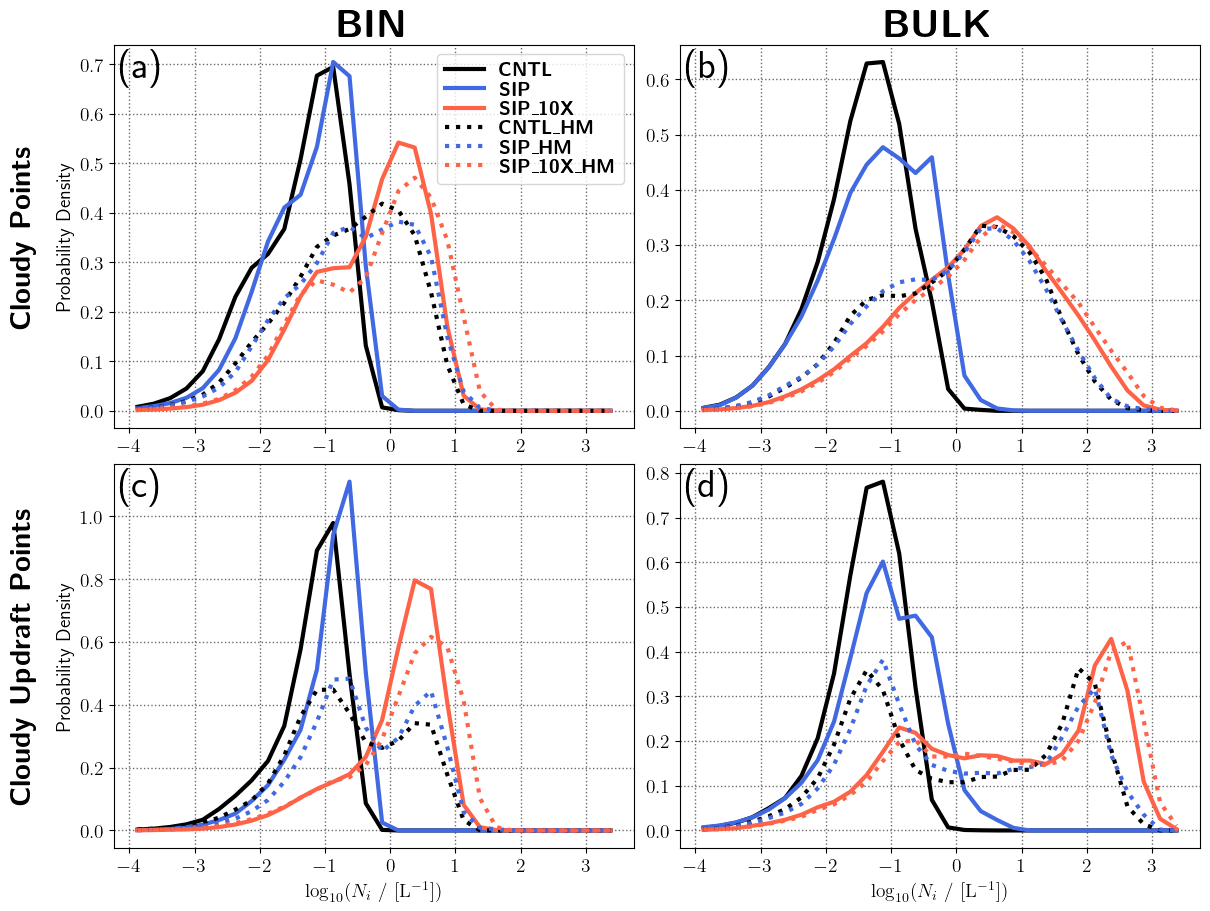

In [9]:
## Normalise to probability density
def to_density(counts, edges):
    total = counts.sum()
    if total == 0:
        return counts.astype(float)
    widths = np.diff(edges)
    return counts / (total * widths)

fig, axes = plt.subplots(2, 2, figsize=(12, 9), constrained_layout=True)
bulk_sim_lws       = [3,3,3,3,3,3]
sim_lws       = [3,3,3,3,3,3]

log10_midbins = np.array([0.5*(log10_edges[dd]+log10_edges[dd+1]) for dd in range(len(log10_edges)-1)])
# 2. Assign the individual axes objects using standard NumPy 2D indexing
ax_bin_cld = axes[0, 0]   # Top-left
ax_bulk_cld = axes[0, 1]  # Top-right
ax_bin_up = axes[1, 0]    # Bottom-left
ax_bulk_up = axes[1, 1]   # Bottom-right


if True:
    for counts, color, lw, ls, name in zip(counts_cld, sim_colors, sim_lws, sim_lss, sim_labels):
        dens = to_density(counts, log10_edges)
        ax_bin_cld.plot(log10_midbins, dens, color=color, lw=lw, linestyle=ls, label=name)
    
    for counts, color, lw, ls, name in zip(bulk_counts_cld, bulk_sim_colors, bulk_sim_lws, bulk_sim_lss, bulk_sim_labels):
        dens = to_density(counts, log10_edges)
        ax_bulk_cld.plot(log10_midbins, dens, color=color, lw=lw, linestyle=ls, label=name)
    
    for counts, color, lw, ls, name in zip(counts_up, sim_colors, sim_lws, sim_lss, sim_labels):
        dens = to_density(counts, log10_edges)
        ax_bin_up.plot(log10_midbins, dens, color=color, lw=lw, linestyle=ls, label=name)
    
    for counts, color, lw, ls, name in zip(bulk_counts_up, bulk_sim_colors, bulk_sim_lws, bulk_sim_lss, bulk_sim_labels):
        dens = to_density(counts, log10_edges)
        ax_bulk_up.plot(log10_midbins, dens, color=color, lw=lw, linestyle=ls, label=name)


if False:
    for counts, color, lw, ls, name in zip(counts_cld, sim_colors, sim_lws, sim_lss, sim_labels):
        dens = to_density(counts, log10_edges)
        ax_bin_cld.plot(log10_midbins, dens, color=color, lw=lw, linestyle=ls, label=name)
    
    for counts, color, lw, ls, name in zip(bulk_counts_cld_qic, bulk_sim_colors, bulk_sim_lws, bulk_sim_lss, bulk_sim_labels):
        dens = to_density(counts, log10_edges)
        ax_bulk_cld.plot(log10_midbins, dens, color=color, lw=lw, linestyle=ls, label=name)
    
    for counts, color, lw, ls, name in zip(counts_up, sim_colors, sim_lws, sim_lss, sim_labels):
        dens = to_density(counts, log10_edges)
        ax_bin_up.plot(log10_midbins, dens, color=color, lw=lw, linestyle=ls, label=name)
    
    for counts, color, lw, ls, name in zip(bulk_counts_up_qic, bulk_sim_colors, bulk_sim_lws, bulk_sim_lss, bulk_sim_labels):
        dens = to_density(counts, log10_edges)
        ax_bulk_up.plot(log10_midbins, dens, color=color, lw=lw, linestyle=ls, label=name)

for ax in axes.flatten():
    ax.tick_params(labelsize=Fontsize)
    ax.grid(ls='dotted', lw=1, c='dimgrey')
    #ax.set_title(title, fontsize=Fontsize * 1.5)
    #ax.set_yscale('log')

ax_bin_cld.legend(fontsize=Fontsize,labelspacing=0.1,loc='upper right')

ax_bin_cld.set_ylabel('Probability Density', fontsize=Fontsize)
ax_bin_up.set_ylabel('Probability Density', fontsize=Fontsize)


ax_bin_cld.text(0.01,0.99,'(a)',fontsize=Fontsize*2.,transform=ax_bin_cld.transAxes,va='top',ha='left')
ax_bulk_cld.text(0.01,0.99,'(b)',fontsize=Fontsize*2.,transform=ax_bulk_cld.transAxes,va='top',ha='left')
ax_bin_up.text(0.01,0.99,'(c)',fontsize=Fontsize*2.,transform=ax_bin_up.transAxes,va='top',ha='left')
ax_bulk_up.text(0.01,0.99,'(d)',fontsize=Fontsize*2.,transform=ax_bulk_up.transAxes,va='top',ha='left')

ax_bin_up.set_xlabel(r'$\log_{10}(N_i\ /\ [\mathrm{L}^{-1}])$', fontsize=Fontsize)
ax_bulk_up.set_xlabel(r'$\log_{10}(N_i\ /\ [\mathrm{L}^{-1}])$', fontsize=Fontsize)

ax_bin_cld.set_title(r'\textbf{BIN}',fontsize=Fontsize*2.)
ax_bulk_cld.set_title(r'\textbf{BULK}',fontsize=Fontsize*2.)

#ax_bin_cld.text(-0.25,0.5,r'\textbf{Cloudy} ($q_{\mathrm{t}}$ $>$ 10$^{-3}$ g kg$^{-1}$)',fontsize=Fontsize*1.25,ha='center',va='center',rotation=90,transform=ax_bin_cld.transAxes)
ax_bin_cld.text(-0.175,0.5,r'\textbf{Cloudy Points}',fontsize=Fontsize*1.5,ha='center',va='center',rotation=90,transform=ax_bin_cld.transAxes)
ax_bin_up.text(-0.175,0.5,r'\textbf{Cloudy Updraft Points}',fontsize=Fontsize*1.5,ha='center',va='center',rotation=90,transform=ax_bin_up.transAxes)

plt.show()


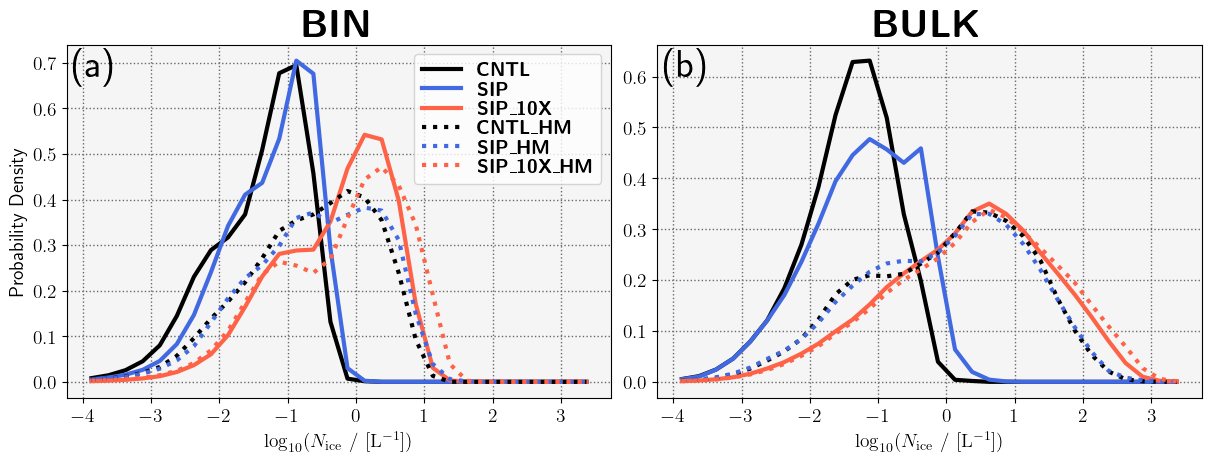

In [12]:
## Normalise to probability density
def to_density(counts, edges):
    total = counts.sum()
    if total == 0:
        return counts.astype(float)
    widths = np.diff(edges)
    return counts / (total * widths)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)
bulk_sim_lws       = [3,3,3,3,3,3]
sim_lws       = [3,3,3,3,3,3]

log10_midbins = np.array([0.5*(log10_edges[dd]+log10_edges[dd+1]) for dd in range(len(log10_edges)-1)])
# 2. Assign the individual axes objects using standard NumPy 2D indexing
ax_bin_cld = axes[0]   # Top-left
ax_bulk_cld = axes[1]  # Top-right
#ax_bin_up = axes[1, 0]    # Bottom-left
#ax_bulk_up = axes[1, 1]   # Bottom-right


for counts, color, lw, ls, name in zip(counts_cld, sim_colors, sim_lws, sim_lss, sim_labels):
    dens = to_density(counts, log10_edges)
    ax_bin_cld.plot(log10_midbins, dens, color=color, lw=lw, linestyle=ls, label=name)

for counts, color, lw, ls, name in zip(bulk_counts_cld, bulk_sim_colors, bulk_sim_lws, bulk_sim_lss, bulk_sim_labels):
    dens = to_density(counts, log10_edges)
    ax_bulk_cld.plot(log10_midbins, dens, color=color, lw=lw, linestyle=ls, label=name)
    

for ax in axes.flatten():
    ax.tick_params(labelsize=Fontsize)
    ax.grid(ls='dotted', lw=1, c='dimgrey')
    #ax.set_title(title, fontsize=Fontsize * 1.5)
    #ax.set_yscale('log')

ax_bin_cld.legend(fontsize=Fontsize,labelspacing=0.1,loc='upper right')

ax_bin_cld.set_ylabel('Probability Density', fontsize=Fontsize)
ax_bin_up.set_ylabel('Probability Density', fontsize=Fontsize)


ax_bin_cld.text(0.01,0.99,'(a)',fontsize=Fontsize*2.,transform=ax_bin_cld.transAxes,va='top',ha='left')
ax_bulk_cld.text(0.01,0.99,'(b)',fontsize=Fontsize*2.,transform=ax_bulk_cld.transAxes,va='top',ha='left')
#ax_bin_up.text(0.01,0.99,'(c)',fontsize=Fontsize*2.,transform=ax_bin_up.transAxes,va='top',ha='left')
#ax_bulk_up.text(0.01,0.99,'(d)',fontsize=Fontsize*2.,transform=ax_bulk_up.transAxes,va='top',ha='left')

ax_bin_cld.set_xlabel(r'$\log_{10}(N_{\mathrm{ice}}\ /\ [\mathrm{L}^{-1}])$', fontsize=Fontsize)
ax_bulk_cld.set_xlabel(r'$\log_{10}(N_{\mathrm{ice}}\ /\ [\mathrm{L}^{-1}])$', fontsize=Fontsize)

ax_bin_cld.set_title(r'\textbf{BIN}',fontsize=Fontsize*2.)
ax_bulk_cld.set_title(r'\textbf{BULK}',fontsize=Fontsize*2.)

#ax_bin_cld.text(-0.25,0.5,r'\textbf{Cloudy} ($q_{\mathrm{t}}$ $>$ 10$^{-3}$ g kg$^{-1}$)',fontsize=Fontsize*1.25,ha='center',va='center',rotation=90,transform=ax_bin_cld.transAxes)
#ax_bin_cld.text(-0.175,0.5,r'\textbf{Cloudy Points}',fontsize=Fontsize*1.5,ha='center',va='center',rotation=90,transform=ax_bin_cld.transAxes)
#ax_bin_up.text(-0.175,0.5,r'\textbf{Cloudy Updraft Points}',fontsize=Fontsize*1.5,ha='center',va='center',rotation=90,transform=ax_bin_up.transAxes)
ax_bulk_cld.set_facecolor('whitesmoke')
ax_bin_cld.set_facecolor('whitesmoke')

plt.show()


In [6]:
post_path = '/pscratch/sd/m/mckenna/dharma_3d/'
inc = 1
bin_cntl_3d_files = sorted(glob.glob(post_path+'cntl_bin_ice/*nc'))[::inc]
bin_cntl_noturb_3d_files = sorted(glob.glob(post_path+'cntl_bin_ice_noturb/*nc'))[::inc]
bin_sip10x_3d_files  = sorted(glob.glob(post_path+'sip_10x_bin_ice/*nc'))[::inc]
bin_sip10x_noturb_3d_files  = sorted(glob.glob(post_path+'sip_10x_bin_ice_noturb/*nc'))[::inc]
                                       
num_bin_cntl_3d_files = len(bin_cntl_3d_files)
num_bin_cntl_noturb_3d_files = len(bin_cntl_noturb_3d_files)
num_bin_sip10x_3d_files = len(bin_sip10x_3d_files)
num_bin_sip10x_noturb_3d_files = len(bin_sip10x_noturb_3d_files)

print(num_bin_cntl_3d_files)
print(num_bin_cntl_noturb_3d_files)
print(num_bin_sip10x_3d_files)
print(num_bin_sip10x_noturb_3d_files)

37
37
37
37


In [7]:
# ============================================================
# PDFs of Ni from 3D BIN simulations
# Left : all cloudy points     (qi > 1e-3 g/kg)
# Right: cloudy updraft points (qi > 1e-3 g/kg AND w_interp > 1 m/s)
# ni [#/cm3] -> L-1 (*1e3); qi threshold = 1e-6 kg/kg
# Histogram counts accumulated file-by-file to avoid memory issues
# ============================================================
Fontsize    = 14
nbins       = 30
log10_edges = np.linspace(-4, 3, nbins + 1)   # L-1 space: 0.01 to 10000
qi_thresh   = 1.e-6    # kg/kg  (= 1e-3 g/kg)
w_thresh    = 1.0      # m/s
ni_thresh   = 1.e-4    # L-1 (exclude near-zero ice)

sim_labels    = [r'\textbf{CNTL}', r'\textbf{SIP\_10X}', r'\textbf{CNTL\_NOTURB}', r'\textbf{SIP\_10X\_NOTURB}']
sim_lws       = [2, 2, 2, 2]
sim_file_lists = [bin_cntl_3d_files, bin_sip10x_3d_files, bin_cntl_noturb_3d_files, bin_sip10x_noturb_3d_files]

# Accumulate counts for each sim (two masks: all cloudy, cloudy updraft)
counts_cld  = []   # one array per sim
counts_up   = []

for i,file_list in enumerate(sim_file_lists):
    print(sim_labels[i])
    c_cld = np.zeros(nbins)
    c_up  = np.zeros(nbins)
    for fpath in file_list:
        with xr.open_dataset(fpath, decode_times=False) as ds_f:
            ni_raw = ds_f['ni'].values.ravel()          # #/cm3
            qi_raw = ds_f['qi'].values.ravel()          # kg/kg
            w_raw  = ds_f['w_interp'].values.ravel()    # m/s

        ni_L = ni_raw * 1.e3                            # -> L-1
        #print(np.max(ni_L))

        mask_cld = (qi_raw > qi_thresh) & (ni_L > ni_thresh)
        mask_up  = mask_cld & (w_raw > w_thresh)

        if mask_cld.any():
            h, _ = np.histogram(np.log10(ni_L[mask_cld]), bins=log10_edges)
            c_cld += h
        if mask_up.any():
            h, _ = np.histogram(np.log10(ni_L[mask_up]),  bins=log10_edges)
            c_up  += h

    counts_cld.append(c_cld)
    counts_up.append(c_up)



\textbf{CNTL}


/global/common/software/m1657/mckenna/flextrkr/lib/python3.11/site-packages/pyproj/__init__.py:89: UserWarning: pyproj unable to set database path.
  _pyproj_global_context_initialize()


\textbf{SIP\_10X}


Exception ignored in: <bound method IPythonKernel._clean_thread_parent_frames of <ipykernel.ipkernel.IPythonKernel object at 0x7fb1f831fd90>>
Traceback (most recent call last):
  File "/global/common/software/m1657/mckenna/flextrkr/lib/python3.11/site-packages/ipykernel/ipkernel.py", line 775, in _clean_thread_parent_frames
    def _clean_thread_parent_frames(

KeyboardInterrupt: 

KeyboardInterrupt



In [ ]:
# Normalise to probability density
def to_density(counts, edges):
    total = counts.sum()
    if total == 0:
        return counts.astype(float)
    widths = np.diff(edges)
    return counts / (total * widths)
sim_colors    = ['k', 'tomato', 'slategrey','lightpink']

fig_pdf3d, (ax_cld, ax_up) = plt.subplots(1, 2, figsize=(12, 5), constrained_layout=True)

for counts, color, lw, name in zip(counts_cld, sim_colors, sim_lws, sim_labels):
    dens = to_density(counts, log10_edges)
    ax_cld.stairs(dens, log10_edges, color=color, lw=lw, linestyle='solid', label=name)
#ax_cld.stairs(to_density(bulk_counts_cld[0],log10_edges),log10_edges,color='teal',lw=lw,linestyle='solid',label=r'\textbf{CNTL BULK}')

for counts, color, lw, name in zip(counts_up, sim_colors, sim_lws, sim_labels):
    dens = to_density(counts, log10_edges)
    ax_up.stairs(dens, log10_edges, color=color, lw=lw, linestyle='solid', label=name)
#ax_up.stairs(to_density(bulk_counts_up[0],log10_edges),log10_edges,color='teal',lw=lw,linestyle='solid',label=r'\textbf{CNTL BULK}')

for ax, title in [(ax_cld, r'\textbf{Cloudy Points}'),
                  (ax_up,  r'\textbf{Cloudy Updraft Points} ')]:
    ax.set_xlabel(r'$\log_{10}(N_i\ /\ [\mathrm{L}^{-1}])$', fontsize=Fontsize)
    ax.tick_params(labelsize=Fontsize)
    ax.grid(ls='dotted', lw=1, c='dimgrey')
    ax.set_title(title, fontsize=Fontsize * 1.2)

ax_cld.legend(fontsize=Fontsize*0.9,edgecolor='k',framealpha=1)
ax_cld.set_ylabel('Probability Density', fontsize=Fontsize)

ax_cld.text(0.01,0.99,'(a)',fontsize=Fontsize*2.,transform=ax_cld.transAxes,va='top',ha='left')
ax_up.text(0.01,0.99,'(b)',fontsize=Fontsize*2.,transform=ax_up.transAxes,va='top',ha='left')

plt.show()


In [9]:

def process_simulation_data(file_list, sim_name, pc_diameters_um):
    """
    Loads and processes a full simulation, returning a dictionary of flattened data.
    """
    print(f"\n--- Processing simulation: {sim_name} ---")
    
    # Initialize master lists to hold data from all time steps
    all_data = {
        'in_cloud': {'ni': []},
        'in_cloudy_updraft': {'ni': []}
    }
    
    # Create boolean masks for cloud/rain bins once
    rain_threshold_diam_um = 100.0
    cloud_bin_mask = pc_diameters_um <= rain_threshold_diam_um
    rain_bin_mask = pc_diameters_um > rain_threshold_diam_um
    cloud_threshold = 0.001 / 1000

    for i, file in enumerate(file_list):
        print(f"  Loading file {i+1}/{len(file_list)}: {file.split('/')[-1]}")
        with xr.open_dataset(file, decode_times=False) as ncfile:
            
            # --- Load Raw Data for this Timestep ---
            tmp_qi = ncfile['qi'].values      # Ice mixing ratio (kg/kg)
            tmp_qni = ncfile['ni'].values     # Total ice number (#/cm3)
            tmp_ql = ncfile['ql'].values      # Liquid mixing ratio (kg/kg)
            tmp_nr_liq = np.array([ncfile[k].values for k in ncfile.keys() if 'liq_num_' in k]) # Binned liquid #/g
            tmp_w = ncfile['w_interp'].values # Vertical velocity (m/s)
            tmp_temp = ncfile['temperature'].values - 273.15 # Temperature (deg C)
            mean_temp = np.mean(tmp_temp,axis=(0,1))

            if i == 0.:
                dumid = np.where( (mean_temp <= 0) & (mean_temp >= -20) )[0] # Limit to mixed-phase region
                tmp_rho = ncfile['rhobar'].values # Air density (kg/m^3)
                tmp_rho = tmp_rho[dumid]

            tmp_w = tmp_w[:,:,dumid]
            tmp_ql = tmp_ql[:,:,dumid]
            tmp_qi = tmp_qi[:,:,dumid]
            tmp_qni = tmp_qni[:,:,dumid]
            #tmp_rho = tmp_rho[dumid]
            tmp_temp = tmp_temp[:,:,dumid]
            #mean_temp = mean_temp[dumid]
            tmp_nr_liq = tmp_nr_liq[:,:,:,dumid]
            #print(np.shape(tmp_nr_liq))

            # --- Calculate 3D Fields for ALL points first ---
            tmp_ni_conc = tmp_qni * 1.e3 # /cm^3 --> /L
            #rho_reshaped = tmp_rho[np.newaxis, np.newaxis, np.newaxis, :]
            #tmp_nr_liq_conc = tmp_nr_liq * rho_reshaped * 1000 * 1e-6 # #/cm^3
            tmp_nr_liq_conc = tmp_nr_liq * tmp_rho * 1.e3 * 1.e-6 # #/cm^3
            tmp_nc_field = np.sum(tmp_nr_liq_conc[cloud_bin_mask, ...], axis=0)
            tmp_nr_field = np.sum(tmp_nr_liq_conc[rain_bin_mask, ...], axis=0)

            
            updraft_threshold_m_s = 1.0
            
            in_cloud_mask = (tmp_ql + tmp_qi > cloud_threshold) & (tmp_temp < 0.) 
            updraft_mask = (tmp_ql + tmp_qi > cloud_threshold) & (tmp_temp < 0.) & (tmp_w > updraft_threshold_m_s)
            
            nc = np.sum(tmp_nr_liq_conc[cloud_bin_mask, ...], axis=0)
            nr = np.sum(tmp_nr_liq_conc[rain_bin_mask, ...], axis=0)
            mmds_cld = calculate_mmd_field_efficient(tmp_nr_liq_conc, in_cloud_mask, pc_diameters_um)
            mmds_updraft = calculate_mmd_field_efficient(tmp_nr_liq_conc, updraft_mask, pc_diameters_um)


            # --- Apply the master masks to all calculated fields ---
            # In-Cloud
            all_data['in_cloud']['ni'].extend(tmp_ni_conc[in_cloud_mask])
            all_data['in_cloud']['nc'].extend(nc[in_cloud_mask])
            all_data['in_cloud']['nr'].extend(nr[in_cloud_mask])
            all_data['in_cloud']['mmd'].extend(mmds_cld) 

            # In-Cloudy-Updraft
            all_data['in_cloudy_updraft']['ni'].extend(tmp_ni_conc[updraft_mask])
            all_data['in_cloudy_updraft']['nc'].extend(nc[updraft_mask])
            all_data['in_cloudy_updraft']['nr'].extend(nr[updraft_mask])
            all_data['in_cloudy_updraft']['mmd'].extend(mmds_updraft) 

    return all_data

In [10]:
# =============================================================================
# --- STEP 3: EXECUTE THE PROCESSING FOR ALL SIMULATIONS ---
# =============================================================================

# Define file lists
post_path = '/pscratch/sd/m/mckenna/dharma_3d/'
inc = 1 # Use 'inc' to subsample files if needed, e.g., inc=2 for every other file
file_lists = {
    'CNTL': sorted(glob.glob(post_path+'cntl_bin_ice/*nc'))[::inc],
    'CNTL_noturb': sorted(glob.glob(post_path+'cntl_bin_ice_noturb/*nc'))[::inc],
    'SIP_10X': sorted(glob.glob(post_path+'sip_10x_bin_ice/*nc'))[::inc],
    'SIP_10X_noturb': sorted(glob.glob(post_path+'sip_10x_bin_ice_noturb/*nc'))[::inc]
}

# Load bin geometry once from the first file
with xr.open_dataset(file_lists['CNTL'][0], decode_times=False) as ncfile:
    pc_radius = ncfile['pc_radius_02'].values # Assumes this is in MICRONS
    pc_diameters_um = pc_radius * 2

# Dictionary to hold the final processed data for all simulations
all_sim_data = {}

# Run the processing for each simulation
for sim_name, f_list in file_lists.items():
    all_sim_data[sim_name] = process_simulation_data(f_list, sim_name, pc_diameters_um)

# --- Verification Print ---
print("\n--- Data Processing Complete. Sample Sizes: ---")
for sim_name, data in all_sim_data.items():
    print(f"  Simulation: {sim_name}")
    print(f"    In-Cloud Ni points: {len(data['in_cloud']['ni'])}")
    print(f"    In-Cloudy-Updraft MMD points: {len(data['in_cloudy_updraft']['mmd'])}")

# Now, the `all_sim_data` dictionary contains everything you need for plotting.
# For example, to get the MMD data for the CNTL_noturb run's updrafts:
# mmd_data = all_sim_data['CNTL_noturb']['in_cloudy_updraft']['mmd']


--- Processing simulation: CNTL ---
  Loading file 1/37: dharma_3d_cntl_bin_ice_021600.nc
  Loading file 2/37: dharma_3d_cntl_bin_ice_022200.nc
  Loading file 3/37: dharma_3d_cntl_bin_ice_022800.nc
  Loading file 4/37: dharma_3d_cntl_bin_ice_023400.nc
  Loading file 5/37: dharma_3d_cntl_bin_ice_024000.nc
  Loading file 6/37: dharma_3d_cntl_bin_ice_024600.nc
  Loading file 7/37: dharma_3d_cntl_bin_ice_025200.nc
  Loading file 8/37: dharma_3d_cntl_bin_ice_025800.nc
  Loading file 9/37: dharma_3d_cntl_bin_ice_026400.nc
  Loading file 10/37: dharma_3d_cntl_bin_ice_027000.nc
  Loading file 11/37: dharma_3d_cntl_bin_ice_027600.nc
  Loading file 12/37: dharma_3d_cntl_bin_ice_028200.nc
  Loading file 13/37: dharma_3d_cntl_bin_ice_028800.nc
  Loading file 14/37: dharma_3d_cntl_bin_ice_029400.nc
  Loading file 15/37: dharma_3d_cntl_bin_ice_030000.nc
  Loading file 16/37: dharma_3d_cntl_bin_ice_030600.nc
  Loading file 17/37: dharma_3d_cntl_bin_ice_031200.nc
  Loading file 18/37: dharma_3d_cntl_

In [11]:
save_path = '/pscratch/sd/m/mckenna/dharma_post/'
file_name = save_path+'bin_noturb_stats.p'
pickle.dump(all_sim_data,open(file_name,"wb")) 

# Load Data

In [12]:
load_path = '/pscratch/sd/m/mckenna/dharma_post/'
file = load_path+'bin_noturb_stats.p'
all_sim_data = pickle.load(open(file,"rb"))

In [13]:
print(all_sim_data.keys())
print(all_sim_data['CNTL'].keys())
print(all_sim_data['CNTL']['in_cloud'].keys())

dict_keys(['CNTL', 'CNTL_noturb', 'SIP_10X', 'SIP_10X_noturb'])
dict_keys(['in_cloud', 'in_cloudy_updraft'])
dict_keys(['ni', 'mmd', 'nc', 'nr'])


In [14]:
# =============================================================================
# --- This part is your histogram calculation script, now with Nc and Nr ---
# =============================================================================
print("\nStarting heavy computation: Calculating all histograms...")


bin_definitions = {
    'nc': np.linspace(-10, 3, 31), 
    'nr': np.linspace(-10, 3, 31), 
    'ni': np.linspace(-4, 3, 31), 
    'mmd': np.linspace(1, 3.7, 31)
}
hist_results = {'cntl': {}, 'cntl_noturb': {}, 'sip_10x': {}, 'sip_10x_noturb':{} }
hist_results_updraft = {'cntl': {}, 'cntl_noturb': {}, 'sip_10x': {}, 'sip_10x_noturb':{} }
hist_results_keys = list(hist_results.keys())

for var_name, bins in bin_definitions.items():
    print(f"  Calculating histogram for: {var_name}")

    for i,key in enumerate(all_sim_data.keys()):

        data_cld = np.array(all_sim_data[key]['in_cloud'][var_name])
        data_cld = data_cld[data_cld > 0.]
        data_updraft = np.array(all_sim_data[key]['in_cloudy_updraft'][var_name])
        data_updraft = data_updraft[data_updraft > 0.]
        data_cld = np.log10(data_cld)
        data_updraft = np.log10(data_updraft)
        counts_cld, _ = np.histogram(data_cld,bins=bins,density=True)
        counts_updraft, _ = np.histogram(data_updraft,bins=bins,density=True)
        hist_results[hist_results_keys[i]][var_name] = counts_cld
        hist_results_updraft[hist_results_keys[i]][var_name] = counts_updraft
        
        #print(key,np.min(data_cld),np.max(data_cld))
        #print(key,np.min(data_updraft),np.max(data_updraft))

output_filename = 'bin_noturb_histograms_log10_cld.npz'
np.savez(output_filename, bin_definitions=bin_definitions, hist_results=hist_results)
print(f"\nAll histograms calculated and saved to: {output_filename}")

output_filename = 'bin_noturb_histograms_log10_updraft.npz'
np.savez(output_filename, bin_definitions=bin_definitions, hist_results=hist_results_updraft)
print(f"\nAll histograms calculated and saved to: {output_filename}")


Starting heavy computation: Calculating all histograms...
  Calculating histogram for: nc
  Calculating histogram for: nr
  Calculating histogram for: ni
  Calculating histogram for: mmd

All histograms calculated and saved to: bin_noturb_histograms_log10_cld.npz

All histograms calculated and saved to: bin_noturb_histograms_log10_updraft.npz


In [15]:
data = np.load('bin_noturb_histograms_log10_cld.npz', allow_pickle=True)
bin_definitions = data['bin_definitions'].item()
hist_results = data['hist_results'].item()

data = np.load('bin_noturb_histograms_log10_updraft.npz', allow_pickle=True)
bin_definitions = data['bin_definitions'].item()
hist_results_updrafts = data['hist_results'].item()

Loading pre-computed histogram data and generating plot...


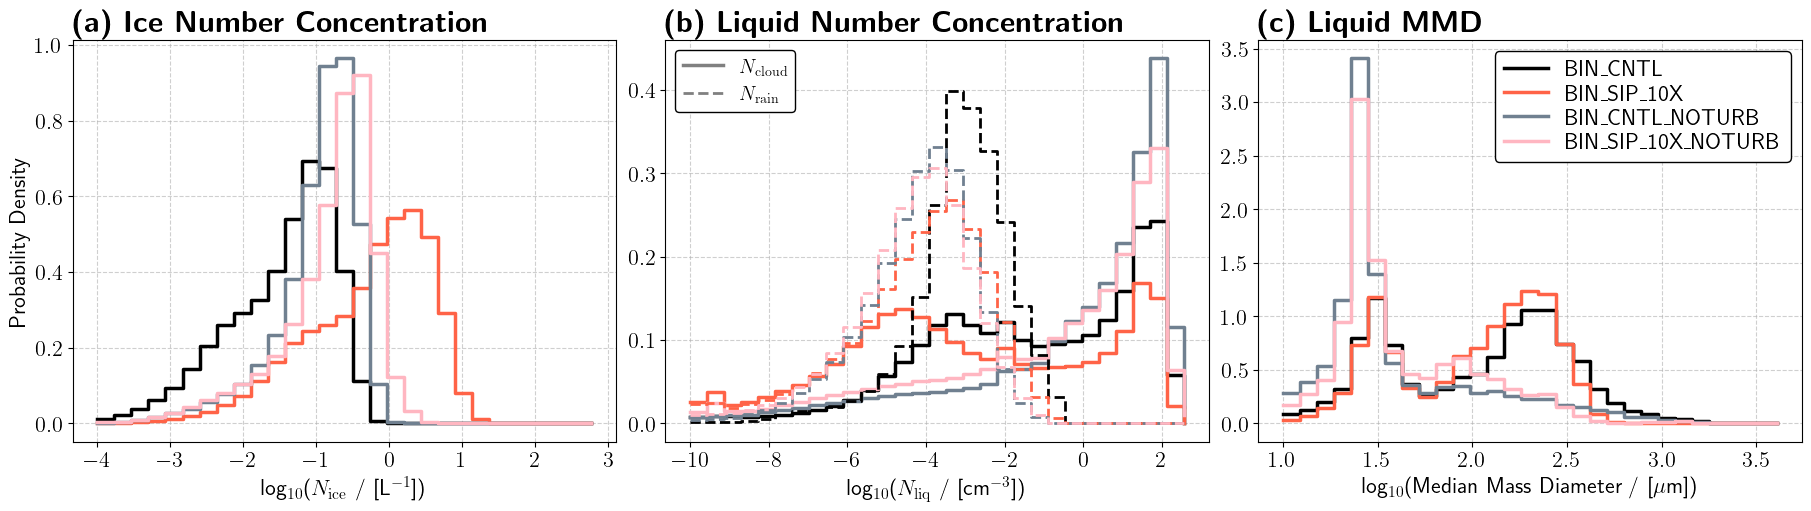

In [16]:
# =============================================================================
# --- This script loads pre-computed histogram data and plots it ---
# =============================================================================
print("Loading pre-computed histogram data and generating plot...")


# --- Define the plotting layout ---
panel_setups = [
    {'key': 'ni', 'title': r'\textbf{(a) Ice Number Concentration}', 'xlabel': r'log$_{10}$($N_{\mathrm{ice}}$ / [L$^{-1}$])'},
    {'key': 'nc', 'title': r'\textbf{(b) Liquid Number Concentration}', 'xlabel': r'log$_{10}$($N_{\mathrm{liq}}$ / [cm$^{-3}$])'},
    {'key': 'mmd', 'title': r'\textbf{(c) Liquid MMD}', 'xlabel': r'log$_{10}$(Median Mass Diameter / [$\mu$m])'}
]

# --- Create the 6-Panel Figure ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5), constrained_layout=True)
axes = axes.flatten()
Fontsize = 16
cntl_color = 'k'
sip_color = 'tomato'
cntl_noturb_color = 'slategrey'
sip_noturb_color = 'lightpink'

y_scale_factor = 1
y_label_text = f'Probability Density'



# --- Loop through and create each panel ---
for i, setup in enumerate(panel_setups):
    ax = axes[i]
    var_key = setup['key']
    
    # --- Special handling for panel (b) ---
    if var_key == 'nc':

        #=====================================
        # All Clouds
        #=====================================
        # Plot Nc (solid)
        ax.step(bin_definitions['nc'][:-1], hist_results['cntl']['nc'] * y_scale_factor, where='post', color=cntl_color, linewidth=2.5, linestyle='solid')
        ax.step(bin_definitions['nc'][:-1], hist_results['sip_10x']['nc'] * y_scale_factor, where='post', color=sip_color, linewidth=2.5, linestyle='solid')
        ax.step(bin_definitions['nc'][:-1], hist_results['cntl_noturb']['nc'] * y_scale_factor, where='post', color=cntl_noturb_color, linewidth=2.5, linestyle='solid')
        ax.step(bin_definitions['nc'][:-1], hist_results['sip_10x_noturb']['nc'] * y_scale_factor, where='post', color=sip_noturb_color, linewidth=2.5, linestyle='solid')
        
        # Plot Nr (dashed) on the same axes
        ax.step(bin_definitions['nr'][:-1], hist_results['cntl']['nr'] * y_scale_factor, where='post', color=cntl_color, linewidth=2.0, linestyle='dashed')
        ax.step(bin_definitions['nr'][:-1], hist_results['sip_10x']['nr'] * y_scale_factor, where='post', color=sip_color, linewidth=2.0, linestyle='dashed')
        ax.step(bin_definitions['nr'][:-1], hist_results['cntl_noturb']['nr'] * y_scale_factor, where='post', color=cntl_noturb_color, linewidth=2.0, linestyle='dashed')
        ax.step(bin_definitions['nr'][:-1], hist_results['sip_10x_noturb']['nr'] * y_scale_factor, where='post', color=sip_noturb_color, linewidth=2.0, linestyle='dashed')
        
        # Create a custom legend for this panel
        legend_elements = [
            Line2D([0], [0], color='gray', lw=2.5, ls='solid', label=r'$N_{\mathrm{cloud}}$'),
            Line2D([0], [0], color='gray', lw=2.0, ls='dashed', label=r'$N_{\mathrm{rain}}$')
        ]
        ax.legend(handles=legend_elements, fontsize=Fontsize*0.9, loc='upper left',framealpha=1,edgecolor='k')



    else:
        # Standard plotting for all other panels
        counts_cntl = hist_results['cntl'][var_key]
        counts_cntl_noturb = hist_results['cntl_noturb'][var_key]
        counts_sip = hist_results['sip_10x'][var_key]
        counts_sip_noturb = hist_results['sip_10x_noturb'][var_key]
        bins = bin_definitions[var_key]
        
        ax.step(bins[:-1], counts_cntl * y_scale_factor, where='post', color=cntl_color, linewidth=2.5, label='BIN_CNTL')
        ax.step(bins[:-1], counts_sip * y_scale_factor, where='post', color=sip_color, linewidth=2.5, label='BIN_SIP_10X')
        ax.step(bins[:-1], counts_cntl_noturb * y_scale_factor, where='post', color=cntl_noturb_color, linewidth=2.5, label='BIN_CNTL_NOTURB')
        ax.step(bins[:-1], counts_sip_noturb * y_scale_factor, where='post', color=sip_noturb_color, linewidth=2.5, label='BIN_SIP_10X_NOTURB')


    # Formatting
    #ax.set_xscale('log')

    ax.set_title(setup['title'], fontsize=Fontsize*1.35, ha='left', x=0.0)
    ax.set_xlabel(setup['xlabel'], fontsize=Fontsize)
    ax.set_ylabel(y_label_text if i % 3 == 0 else '', fontsize=Fontsize)
    ax.tick_params(labelsize=Fontsize)
    ax.grid(True, which='both', linestyle='--', alpha=0.6)
    #ax.set_xticklabels([])
    
    # Set y-limit, but get it from the scaled data
    #if i != 1: # Don't apply auto-limits to the special Nc/Nr plot
    #  max_y = max(np.max(hist_results['cntl'][var_key]), np.max(hist_results['sip_10x'][var_key])) * y_scale_factor
    #  ax.set_ylim(0, max_y * 1.1)

# Add the main legend to the first panel
#axes[0].legend(fontsize=Fontsize*0.75, loc='upper right',edgecolor='k',framealpha=1,labelspacing=0.2)
axes[2].legend(fontsize=Fontsize, loc='upper right',edgecolor='k',framealpha=1,labelspacing=0.2)

plt.show()

Loading pre-computed histogram data and generating plot...


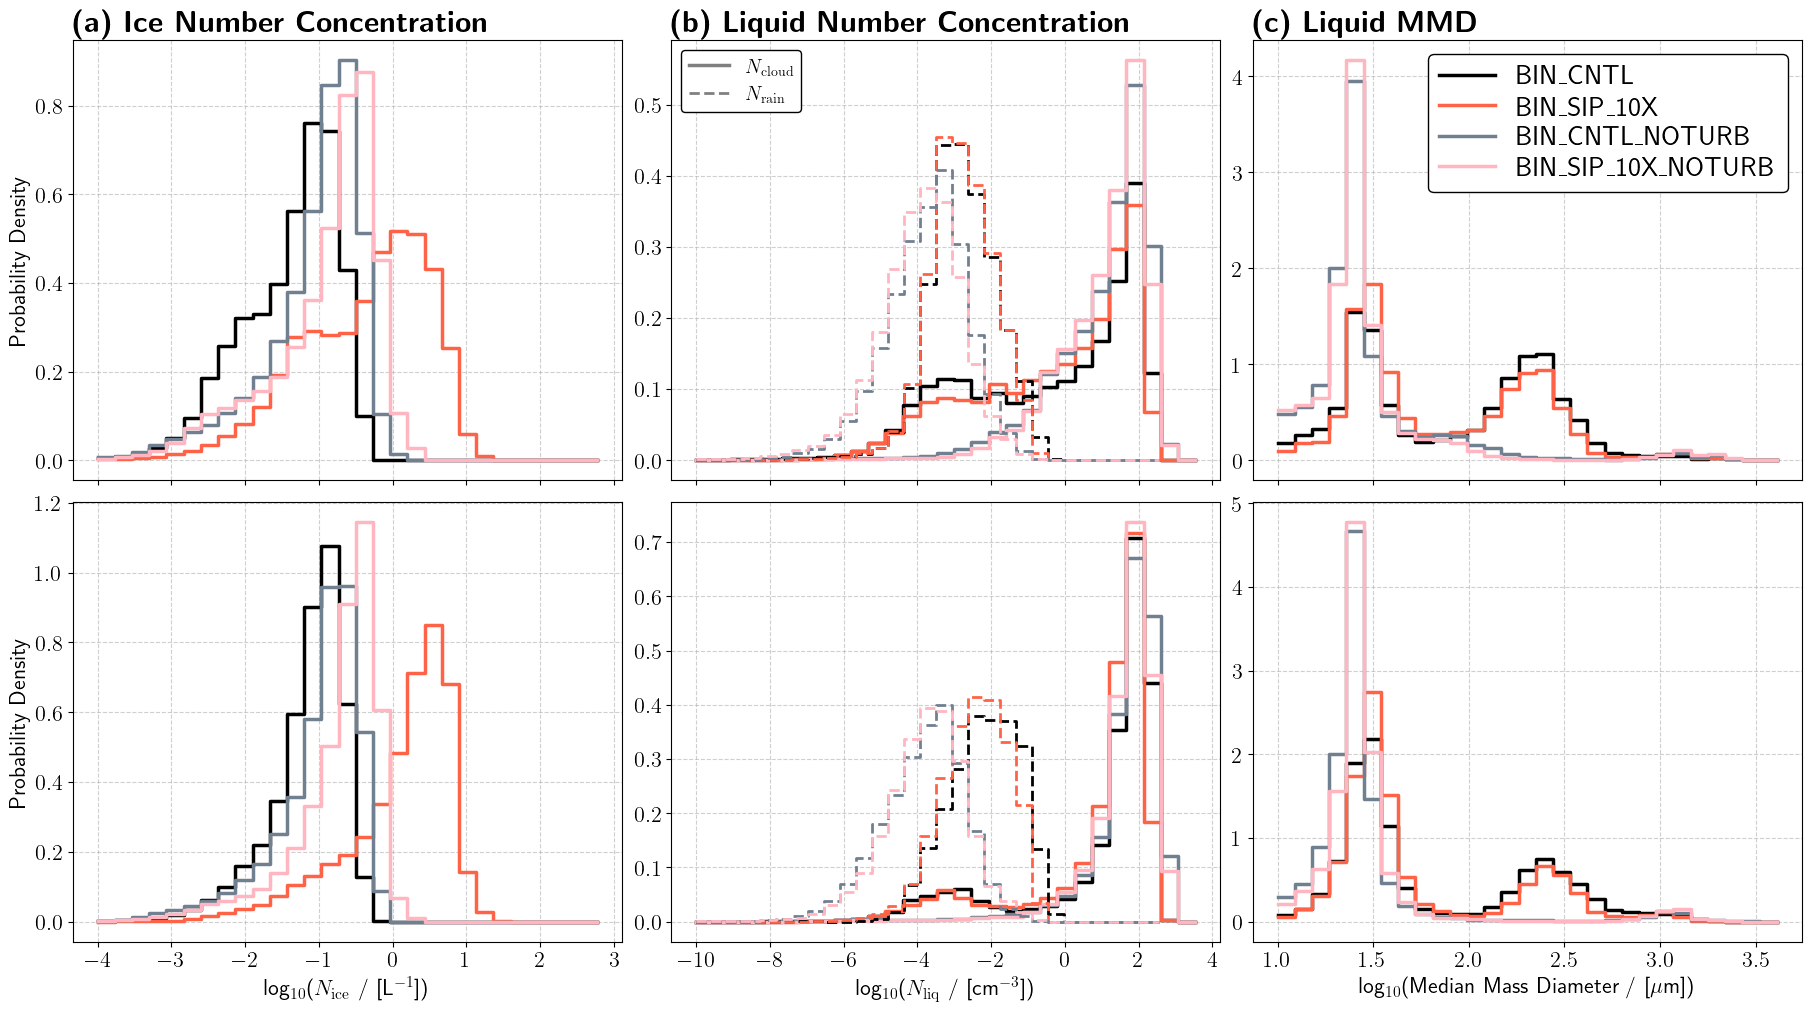

In [136]:
# =============================================================================
# --- This script loads pre-computed histogram data and plots it ---
# =============================================================================
print("Loading pre-computed histogram data and generating plot...")


# --- Define the plotting layout ---
panel_setups = [
    {'key': 'ni', 'title': r'\textbf{(a) Ice Number Concentration}', 'xlabel': r'log$_{10}$($N_{\mathrm{ice}}$ / [L$^{-1}$])'},
    {'key': 'nc', 'title': r'\textbf{(b) Liquid Number Concentration}', 'xlabel': r'log$_{10}$($N_{\mathrm{liq}}$ / [cm$^{-3}$])'},
    {'key': 'mmd', 'title': r'\textbf{(c) Liquid MMD}', 'xlabel': r'log$_{10}$(Median Mass Diameter / [$\mu$m])'}
]

# --- Create the 6-Panel Figure ---
fig, axes = plt.subplots(2, 3, figsize=(18, 10), constrained_layout=True)
axes = axes.flatten()
Fontsize = 16
cntl_color = 'k'
sip_color = 'tomato'
cntl_noturb_color = 'slategrey'
sip_noturb_color = 'lightpink'

y_scale_factor = 1
y_label_text = f'Probability Density'



# --- Loop through and create each panel ---
for i, setup in enumerate(panel_setups):
    ax = axes[i]
    ax2 = axes[i+3]
    var_key = setup['key']
    
    # --- Special handling for panel (b) ---
    if var_key == 'nc':

        #=====================================
        # All Clouds
        #=====================================
        # Plot Nc (solid)
        ax.step(bin_definitions['nc'][:-1], hist_results['cntl']['nc'] * y_scale_factor, where='post', color=cntl_color, linewidth=2.5, linestyle='solid')
        ax.step(bin_definitions['nc'][:-1], hist_results['sip_10x']['nc'] * y_scale_factor, where='post', color=sip_color, linewidth=2.5, linestyle='solid')
        ax.step(bin_definitions['nc'][:-1], hist_results['cntl_noturb']['nc'] * y_scale_factor, where='post', color=cntl_noturb_color, linewidth=2.5, linestyle='solid')
        ax.step(bin_definitions['nc'][:-1], hist_results['sip_10x_noturb']['nc'] * y_scale_factor, where='post', color=sip_noturb_color, linewidth=2.5, linestyle='solid')
        
        # Plot Nr (dashed) on the same axes
        ax.step(bin_definitions['nr'][:-1], hist_results['cntl']['nr'] * y_scale_factor, where='post', color=cntl_color, linewidth=2.0, linestyle='dashed')
        ax.step(bin_definitions['nr'][:-1], hist_results['sip_10x']['nr'] * y_scale_factor, where='post', color=sip_color, linewidth=2.0, linestyle='dashed')
        ax.step(bin_definitions['nr'][:-1], hist_results['cntl_noturb']['nr'] * y_scale_factor, where='post', color=cntl_noturb_color, linewidth=2.0, linestyle='dashed')
        ax.step(bin_definitions['nr'][:-1], hist_results['sip_10x_noturb']['nr'] * y_scale_factor, where='post', color=sip_noturb_color, linewidth=2.0, linestyle='dashed')
        
        # Create a custom legend for this panel
        legend_elements = [
            Line2D([0], [0], color='gray', lw=2.5, ls='solid', label=r'$N_{\mathrm{cloud}}$'),
            Line2D([0], [0], color='gray', lw=2.0, ls='dashed', label=r'$N_{\mathrm{rain}}$')
        ]
        ax.legend(handles=legend_elements, fontsize=Fontsize*0.9, loc='upper left',framealpha=1,edgecolor='k')

        #=====================================
        # Updrafts
        #=====================================
        # Plot Nc (solid)
        ax2.step(bin_definitions['nc'][:-1], hist_results_updrafts['cntl']['nc'] * y_scale_factor, where='post', color=cntl_color, linewidth=2.5, linestyle='solid')
        ax2.step(bin_definitions['nc'][:-1], hist_results_updrafts['sip_10x']['nc'] * y_scale_factor, where='post', color=sip_color, linewidth=2.5, linestyle='solid')
        ax2.step(bin_definitions['nc'][:-1], hist_results_updrafts['cntl_noturb']['nc'] * y_scale_factor, where='post', color=cntl_noturb_color, linewidth=2.5, linestyle='solid')
        ax2.step(bin_definitions['nc'][:-1], hist_results_updrafts['sip_10x_noturb']['nc'] * y_scale_factor, where='post', color=sip_noturb_color, linewidth=2.5, linestyle='solid')
        
        # Plot Nr (dashed) on the same axes
        ax2.step(bin_definitions['nr'][:-1], hist_results_updrafts['cntl']['nr'] * y_scale_factor, where='post', color=cntl_color, linewidth=2.0, linestyle='dashed')
        ax2.step(bin_definitions['nr'][:-1], hist_results_updrafts['sip_10x']['nr'] * y_scale_factor, where='post', color=sip_color, linewidth=2.0, linestyle='dashed')
        ax2.step(bin_definitions['nr'][:-1], hist_results_updrafts['cntl_noturb']['nr'] * y_scale_factor, where='post', color=cntl_noturb_color, linewidth=2.0, linestyle='dashed')
        ax2.step(bin_definitions['nr'][:-1], hist_results_updrafts['sip_10x_noturb']['nr'] * y_scale_factor, where='post', color=sip_noturb_color, linewidth=2.0, linestyle='dashed')
         

    else:
        # Standard plotting for all other panels
        counts_cntl = hist_results['cntl'][var_key]
        counts_cntl_noturb = hist_results['cntl_noturb'][var_key]
        counts_sip = hist_results['sip_10x'][var_key]
        counts_sip_noturb = hist_results['sip_10x_noturb'][var_key]
        bins = bin_definitions[var_key]
        
        ax.step(bins[:-1], counts_cntl * y_scale_factor, where='post', color=cntl_color, linewidth=2.5, label='BIN_CNTL')
        ax.step(bins[:-1], counts_sip * y_scale_factor, where='post', color=sip_color, linewidth=2.5, label='BIN_SIP_10X')
        ax.step(bins[:-1], counts_cntl_noturb * y_scale_factor, where='post', color=cntl_noturb_color, linewidth=2.5, label='BIN_CNTL_NOTURB')
        ax.step(bins[:-1], counts_sip_noturb * y_scale_factor, where='post', color=sip_noturb_color, linewidth=2.5, label='BIN_SIP_10X_NOTURB')

        counts_cntl = hist_results_updraft['cntl'][var_key]
        counts_cntl_noturb = hist_results_updraft['cntl_noturb'][var_key]
        counts_sip = hist_results_updraft['sip_10x'][var_key]
        counts_sip_noturb = hist_results_updraft['sip_10x_noturb'][var_key]
        bins = bin_definitions[var_key]
        
        ax2.step(bins[:-1], counts_cntl * y_scale_factor, where='post', color=cntl_color, linewidth=2.5, label='BIN_CNTL')
        ax2.step(bins[:-1], counts_sip * y_scale_factor, where='post', color=sip_color, linewidth=2.5, label='BIN_SIP_10X')
        ax2.step(bins[:-1], counts_cntl_noturb * y_scale_factor, where='post', color=cntl_noturb_color, linewidth=2.5, label='BIN_CNTL_NOTURB')
        ax2.step(bins[:-1], counts_sip_noturb * y_scale_factor, where='post', color=sip_noturb_color, linewidth=2.5, label='BIN_SIP_10X_NOTURB')
        
    # Formatting
    #ax.set_xscale('log')

    ax.set_title(setup['title'], fontsize=Fontsize*1.35, ha='left', x=0.0)
    ax2.set_xlabel(setup['xlabel'], fontsize=Fontsize)
    ax.set_ylabel(y_label_text if i % 3 == 0 else '', fontsize=Fontsize)
    ax2.set_ylabel(y_label_text if i % 3 == 0 else '', fontsize=Fontsize)
    ax.tick_params(labelsize=Fontsize)
    ax2.tick_params(labelsize=Fontsize)
    ax.grid(True, which='both', linestyle='--', alpha=0.6)
    ax2.grid(True, which='both', linestyle='--', alpha=0.6)
    ax.set_xticklabels([])
    
    # Set y-limit, but get it from the scaled data
    #if i != 1: # Don't apply auto-limits to the special Nc/Nr plot
    #  max_y = max(np.max(hist_results['cntl'][var_key]), np.max(hist_results['sip_10x'][var_key])) * y_scale_factor
    #  ax.set_ylim(0, max_y * 1.1)

# Add the main legend to the first panel
#axes[0].legend(fontsize=Fontsize*0.75, loc='upper right',edgecolor='k',framealpha=1,labelspacing=0.2)
axes[2].legend(fontsize=Fontsize*1.25, loc='upper right',edgecolor='k',framealpha=1,labelspacing=0.2)

plt.show()

/tmp/ipykernel_617192/2043699873.py:41: UserWarning: Log scale: values of z <= 0 have been masked
  pm_bin_turb.append(  axes2[0, col].contourf(t_t, zt_t, Ni_t.T, **bin_kw))
/tmp/ipykernel_617192/2043699873.py:42: UserWarning: Log scale: values of z <= 0 have been masked
  pm_bin_noturb.append(axes2[1, col].contourf(t_n, zt_n, Ni_n.T, **bin_kw))


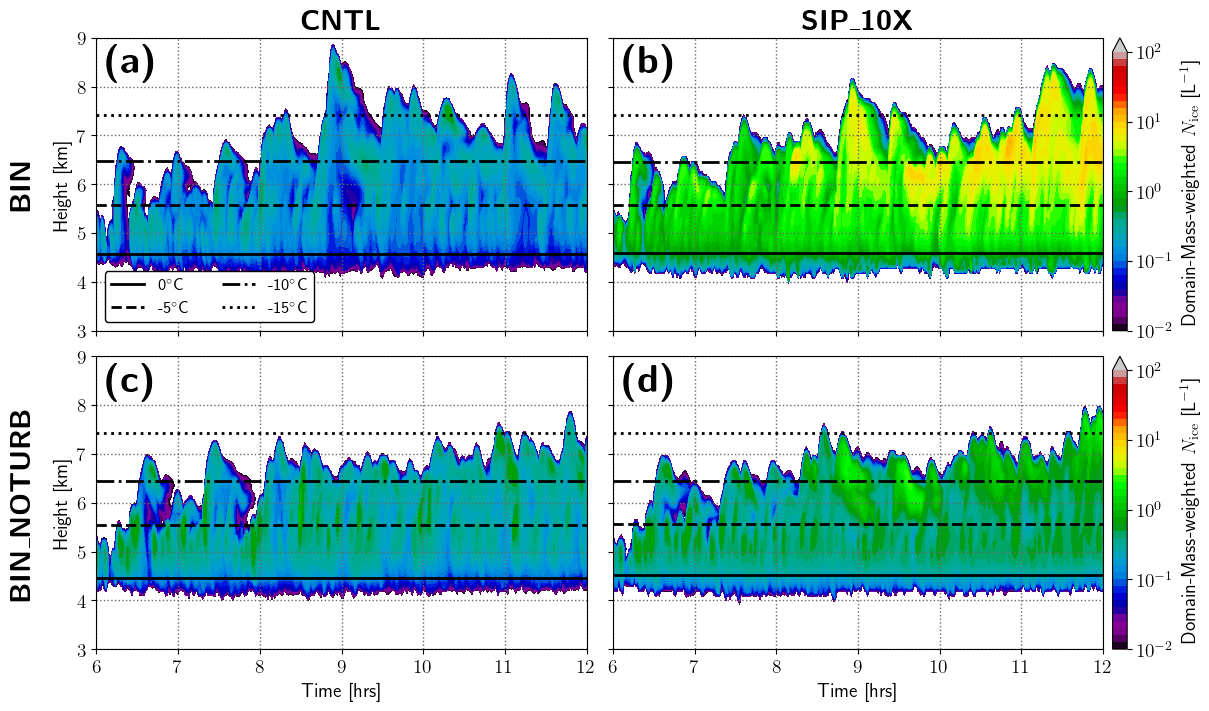

In [13]:
# ---------------------------------------------------------------------------
# BIN turb (top) vs BIN noturb (bottom) — same layout as the BIN/BULK figure
# ---------------------------------------------------------------------------
# ---------------------------------------------------------------------------
# Unpack time and grids (bin: time in s -> hours; bulk: tmp_time already hours)
# ---------------------------------------------------------------------------
def bin_time(d):     return d['time'] / 3600.
def bulk_time(d):    return d['tmp_time']
def get_zt(d):       return np.asarray(d['zt'])  * 1.e-3   # m -> km
def get_var(d, key): return d[key] * 1.e3                   # cm-3 -> L-1
def get_T(d):        return d['T']                          # K

bin_var_key  = 'nqif'   # swap to 'nqif'  if desired
bin_label    = r'Domain-Mass-weighted $N_{\mathrm{ice}}$ [L$^{-1}$]'

Fontsize    = 14
panel_props = dict(boxstyle='square', facecolor='white', alpha=0.85,
                   edgecolor='k', linewidth=0.8, pad=0.2)
panel_ids   = [r'\textbf{(a)}', r'\textbf{(b)}', r'\textbf{(c)}', r'\textbf{(d)}']
col_titles  = [r'\textbf{CNTL}', r'\textbf{SIP\_10X}']
row_labels  = [r'\textbf{BIN}', r'\textbf{BIN\_NOTURB}']

turb_bin_dicts  = [bin_dict,bin_sip_10x_dict]
noturb_bin_dicts = [bin_noturb_dict, bin_sip_10x_noturb_dict]
row_labels_noturb = [r'\textbf{BIN}', r'\textbf{BIN\_NOTURB}']
cmap = 'nipy_spectral'

bin_levels   = 10.**np.arange(-2, 2.1, 0.1)
bin_norm     = matplotlib.colors.LogNorm(vmin=1.e-2, vmax=1.e2)
bin_kw       = dict(cmap=cmap, levels=bin_levels, norm=bin_norm, extend='max')
bin_cb_ticks = 10.**np.arange(-2, 3, 1)


fig2, axes2 = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)

pm_bin_turb   = []
pm_bin_noturb = []
for col, (td, nd) in enumerate(zip(turb_bin_dicts, noturb_bin_dicts)):
    t_t  = bin_time(td);   zt_t = get_zt(td);   Ni_t = get_var(td, bin_var_key)
    t_n  = bin_time(nd);   zt_n = get_zt(nd);   Ni_n = get_var(nd, bin_var_key)
    pm_bin_turb.append(  axes2[0, col].contourf(t_t, zt_t, Ni_t.T, **bin_kw))
    pm_bin_noturb.append(axes2[1, col].contourf(t_n, zt_n, Ni_n.T, **bin_kw))

cb_turb   = fig2.colorbar(pm_bin_turb[0],   ax=axes2[0, :].tolist(),
                           location='right', pad=0.0, ticks=bin_cb_ticks)
cb_noturb = fig2.colorbar(pm_bin_noturb[0], ax=axes2[1, :].tolist(),
                           location='right', pad=0.0, ticks=bin_cb_ticks)
for cb in [cb_turb, cb_noturb]:
    cb.ax.tick_params(labelsize=Fontsize)
    cb.set_label(bin_label, fontsize=Fontsize)

for row, dicts in enumerate([turb_bin_dicts, noturb_bin_dicts]):
    for col, d in enumerate(dicts):
        ax = axes2[row, col]
        ax.tick_params(labelsize=Fontsize)
        ax.grid(ls='dotted', lw=1, c='dimgrey')
        #ax.set_xlabel('Time [hrs]', fontsize=Fontsize)

        # x-axis labels only on bottom row
        if row == 1:
            ax.set_xlabel('Time [hrs]', fontsize=Fontsize)
        else:
            ax.tick_params(axis='x', labelbottom=False)
        
        if col == 0:
            ax.set_ylabel('Height [km]', fontsize=Fontsize)
        else:
            ax.tick_params(axis='y', labelleft=False)
            ax.set_ylabel('')
        ax.set_xlim(6, 12)
        ax.set_ylim(3, 9)
        ax.text(0.02, 0.98, panel_ids[row * 2 + col], fontsize=Fontsize*2,
                fontweight='bold', c='k', transform=ax.transAxes,
                va='top', ha='left', zorder=5)

    axes2[row, 0].text(-0.15, 0.5, row_labels_noturb[row], fontsize=Fontsize * 1.5,
                       fontweight='bold', c='k', transform=axes2[row, 0].transAxes,
                       va='center', ha='center', rotation=90)

for col, title in enumerate(col_titles):
    axes2[0, col].set_title(title, fontsize=Fontsize * 1.5)

tmp_color = 'k'
T_levels = [(0,   tmp_color, 'solid'),
            (-5,  tmp_color, 'dashed'),
            (-10, tmp_color, '-.'),
            (-15, tmp_color, 'dotted')]
dumstr = '$^{\circ}$C'

# Mean-T isotherms
for row, dicts in enumerate([turb_bin_dicts, noturb_bin_dicts]):
    for col, d in enumerate(dicts):
        ax   = axes2[row, col]
        zt_d = get_zt(d);   T_d = get_T(d);   t_d = bin_time(d)
        last6_mask = t_d >= (t_d[-1] - 6.)
        T_mean = np.mean(T_d[last6_mask, :], axis=0) - 273.15
        for level, color, ls in T_levels:
            z_lev = np.interp(level, T_mean[::-1], zt_d[::-1])
            ax.axhline(z_lev, color=color, ls=ls, lw=2)
legend_lines  = [Line2D([0], [0], color=c, lw=2, ls=ls) for _, c, ls in T_levels]
legend_labels = [str(int(lv)) + dumstr for lv, _, _ in T_levels]
lgnd2 = axes2[0, 0].legend(legend_lines, legend_labels, loc='lower left',
                             bbox_to_anchor=(0., 0.), fontsize=Fontsize*0.85, ncol=2,
                             framealpha=True, edgecolor='k')

plt.show()


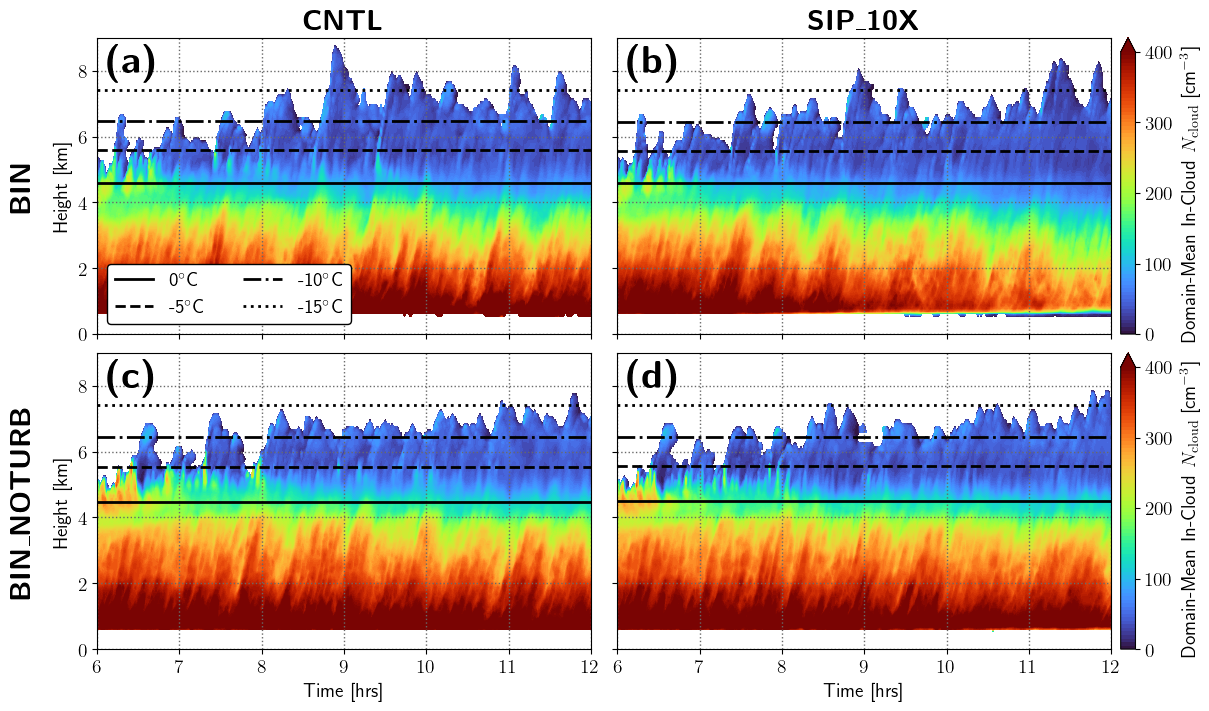

In [11]:
# ---------------------------------------------------------------------------
# BIN turb (top) vs BIN noturb (bottom) — same layout as the BIN/BULK figure
# ---------------------------------------------------------------------------
# ---------------------------------------------------------------------------
# Unpack time and grids (bin: time in s -> hours; bulk: tmp_time already hours)
# ---------------------------------------------------------------------------
def bin_time(d):     return d['time'] / 3600.
def bulk_time(d):    return d['tmp_time']
def get_zt(d):       return np.asarray(d['zt'])  * 1.e-3   # m -> km
def get_var(d, key): return d[key]
def get_T(d):        return d['T']                          # K

bin_var_key  = 'nc_cld'   # swap to 'nqif'  if desired
bin_label    = r'Domain-Mean In-Cloud $N_{\mathrm{cloud}}$ [cm$^{-3}$]'

Fontsize    = 14
panel_props = dict(boxstyle='square', facecolor='white', alpha=0.85,
                   edgecolor='k', linewidth=0.8, pad=0.2)
panel_ids   = [r'\textbf{(a)}', r'\textbf{(b)}', r'\textbf{(c)}', r'\textbf{(d)}']
col_titles  = [r'\textbf{CNTL}', r'\textbf{SIP\_10X}']
row_labels  = [r'\textbf{BIN}', r'\textbf{BIN\_NOTURB}']

turb_bin_dicts  = [bin_dict,bin_sip_10x_dict]
noturb_bin_dicts = [bin_noturb_dict, bin_sip_10x_noturb_dict]
row_labels_noturb = [r'\textbf{BIN}', r'\textbf{BIN\_NOTURB}']
cmap = 'turbo'

bin_levels   = np.arange(0,405,5)
bin_norm     = None
bin_kw       = dict(cmap=cmap, levels=bin_levels, norm=bin_norm, extend='max')
bin_cb_ticks = np.arange(0,500,100)


fig2, axes2 = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)

pm_bin_turb   = []
pm_bin_noturb = []
for col, (td, nd) in enumerate(zip(turb_bin_dicts, noturb_bin_dicts)):
    t_t  = bin_time(td);   zt_t = get_zt(td);   var_t = get_var(td, bin_var_key)
    t_n  = bin_time(nd);   zt_n = get_zt(nd);   var_n = get_var(nd, bin_var_key)
    var_t[var_t == 0.] = np.nan
    var_n[var_n == 0.] = np.nan
    pm_bin_turb.append(  axes2[0, col].contourf(t_t, zt_t, var_t.T, **bin_kw))
    pm_bin_noturb.append(axes2[1, col].contourf(t_n, zt_n, var_n.T, **bin_kw))

cb_turb   = fig2.colorbar(pm_bin_turb[0],   ax=axes2[0, :].tolist(),
                           location='right', pad=0.0, ticks=bin_cb_ticks)
cb_noturb = fig2.colorbar(pm_bin_noturb[0], ax=axes2[1, :].tolist(),
                           location='right', pad=0.0, ticks=bin_cb_ticks)
for cb in [cb_turb, cb_noturb]:
    cb.ax.tick_params(labelsize=Fontsize)
    cb.set_label(bin_label, fontsize=Fontsize)

for row, dicts in enumerate([turb_bin_dicts, noturb_bin_dicts]):
    for col, d in enumerate(dicts):
        ax = axes2[row, col]
        ax.tick_params(labelsize=Fontsize)
        ax.grid(ls='dotted', lw=1, c='dimgrey')
        #ax.set_xlabel('Time [hrs]', fontsize=Fontsize)

        # x-axis labels only on bottom row
        if row == 1:
            ax.set_xlabel('Time [hrs]', fontsize=Fontsize)
        else:
            ax.tick_params(axis='x', labelbottom=False)
        
        if col == 0:
            ax.set_ylabel('Height [km]', fontsize=Fontsize)
        else:
            ax.tick_params(axis='y', labelleft=False)
            ax.set_ylabel('')
        ax.set_xlim(6, 12)
        ax.set_ylim(0, 9)
        ax.text(0.02, 0.98, panel_ids[row * 2 + col], fontsize=Fontsize*2,
                fontweight='bold', c='k', transform=ax.transAxes,
                va='top', ha='left', zorder=5)

    axes2[row, 0].text(-0.15, 0.5, row_labels_noturb[row], fontsize=Fontsize * 1.5,
                       fontweight='bold', c='k', transform=axes2[row, 0].transAxes,
                       va='center', ha='center', rotation=90)

for col, title in enumerate(col_titles):
    axes2[0, col].set_title(title, fontsize=Fontsize * 1.5)

tmp_color = 'k'
T_levels = [(0,   tmp_color, 'solid'),
            (-5,  tmp_color, 'dashed'),
            (-10, tmp_color, '-.'),
            (-15, tmp_color, 'dotted')]
dumstr = '$^{\circ}$C'

# Mean-T isotherms
for row, dicts in enumerate([turb_bin_dicts, noturb_bin_dicts]):
    for col, d in enumerate(dicts):
        ax   = axes2[row, col]
        zt_d = get_zt(d);   T_d = get_T(d);   t_d = bin_time(d)
        last6_mask = t_d >= (t_d[-1] - 6.)
        T_mean = np.mean(T_d[last6_mask, :], axis=0) - 273.15
        for level, color, ls in T_levels:
            z_lev = np.interp(level, T_mean[::-1], zt_d[::-1])
            ax.axhline(z_lev, color=color, ls=ls, lw=2)
legend_lines  = [Line2D([0], [0], color=c, lw=2, ls=ls) for _, c, ls in T_levels]
legend_labels = [str(int(lv)) + dumstr for lv, _, _ in T_levels]
lgnd2 = axes2[0, 0].legend(legend_lines, legend_labels, loc='lower left',
                             bbox_to_anchor=(0., 0.), fontsize=Fontsize, ncol=2,
                             framealpha=True, edgecolor='k')

plt.show()
